Heatmaps generated successfully!

Data Overview:
- Minibus Capacities: [np.int64(6), np.int64(8)]
- Minibus Ratios: [np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5)]
- Total Experiments: 8


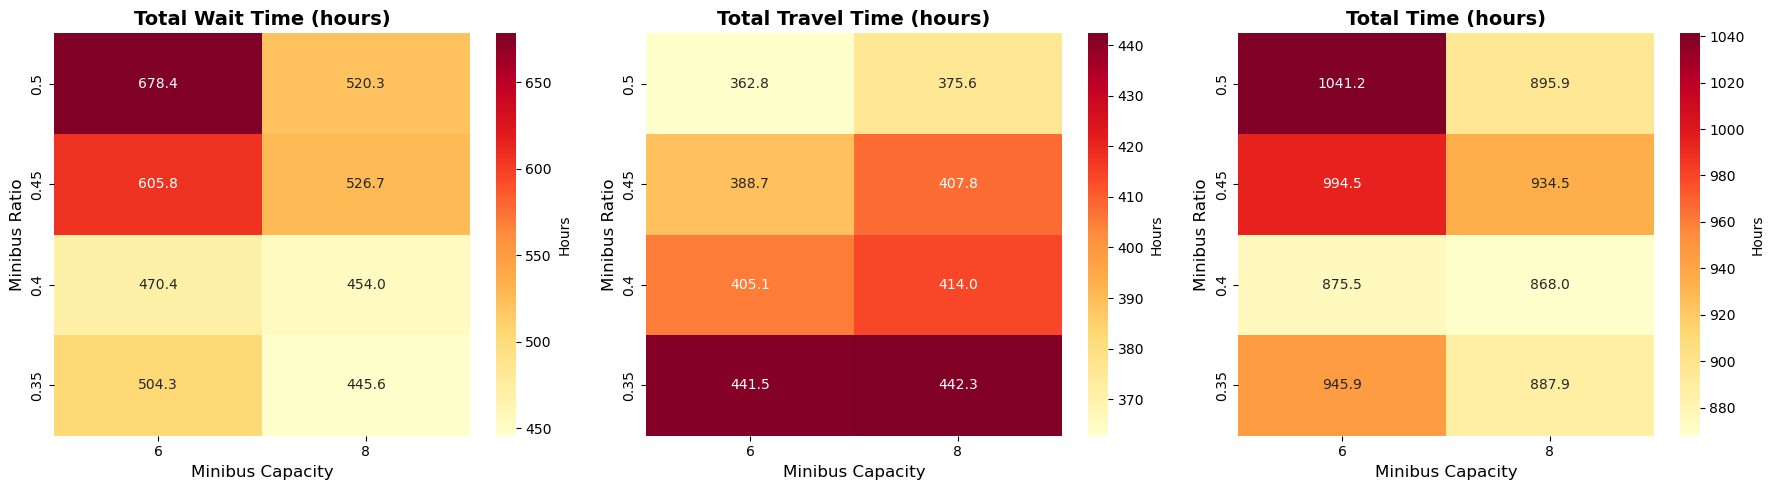

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read CSV file
df = pd.read_csv('Minibus_ratio_results_2/experiment_summary.csv')

# Create three heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Prepare data - create pivot tables for each metric
metrics = [
    ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
    ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
    ('total_total_time_hours', 'Total Time (hours)', axes[2])
]

for metric_col, title, ax in metrics:
    # Create pivot table with capacity as columns
    pivot_data = df.pivot_table(
        values=metric_col,
        index='minibus_ratio',
        columns='minibus_capacity',
        aggfunc='mean'
    )
    
    # Plot heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        ax=ax,
        cbar_kws={'label': 'Hours'}
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Minibus Capacity', fontsize=12)
    ax.set_ylabel('Minibus Ratio', fontsize=12)
    
    # Invert y-axis so ratio goes from small to large
    ax.invert_yaxis()

plt.tight_layout()


print("Heatmaps generated successfully!")
print(f"\nData Overview:")
print(f"- Minibus Capacities: {sorted(df['minibus_capacity'].unique())}")
print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
print(f"- Total Experiments: {len(df)}")

3D heatmaps generated successfully!

Data Overview:
- Minibus Capacities: [np.int64(6), np.int64(8)]
- Minibus Ratios: [np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5)]
- Number of Minibuses: [np.int64(3)]
- Total Experiments: 8


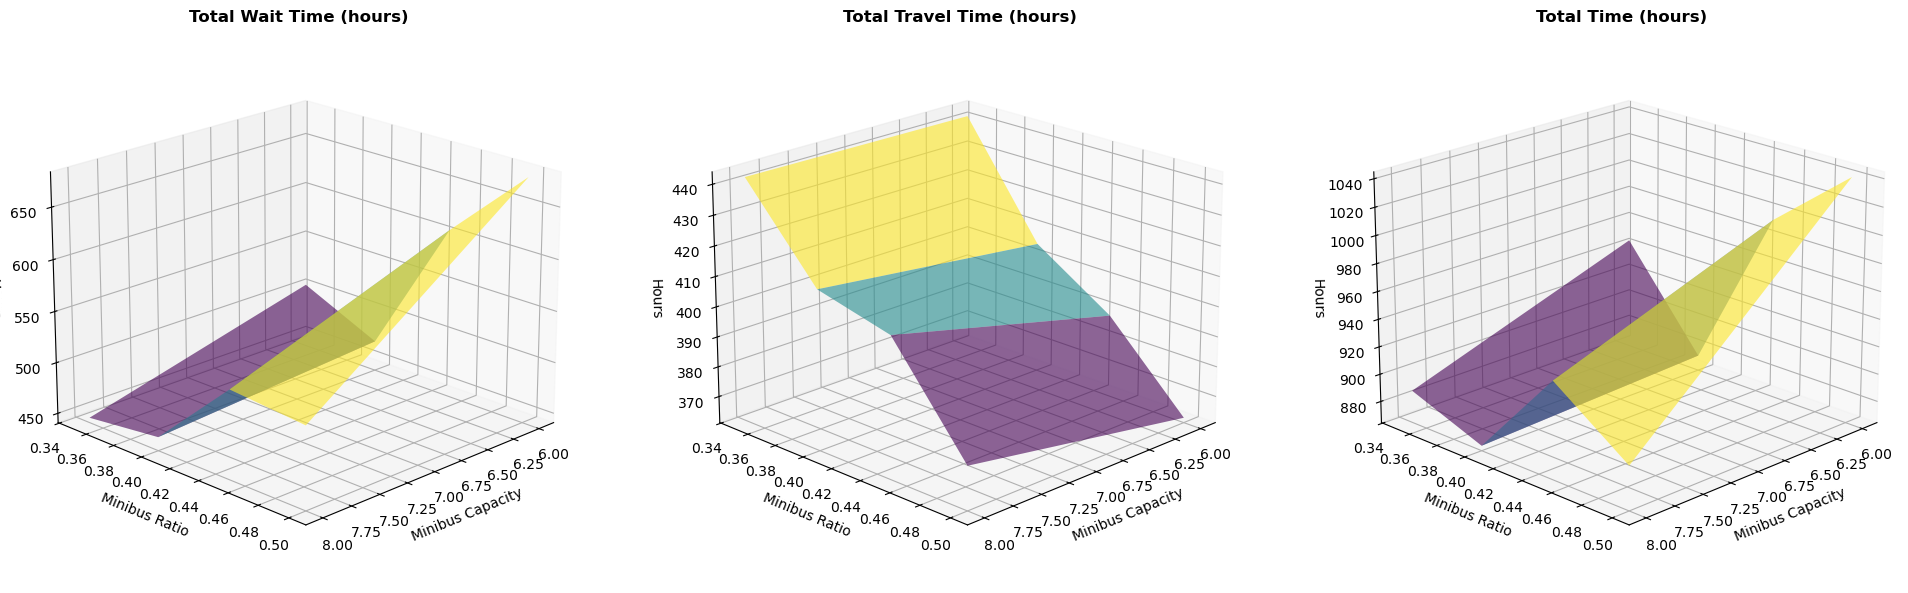

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Read CSV file
df = pd.read_csv('Minibus_ratio_results/experiment_summary.csv')

# Create figure with 3 subplots for 3D visualization
fig = plt.figure(figsize=(20, 6))

# Metrics to plot
metrics = [
    ('total_wait_time_hours', 'Total Wait Time (hours)'),
    ('total_travel_time_hours', 'Total Travel Time (hours)'),
    ('total_total_time_hours', 'Total Time (hours)')
]

for idx, (metric_col, title) in enumerate(metrics, 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    
    # Get unique values for each dimension
    capacities = sorted(df['minibus_capacity'].unique())
    ratios = sorted(df['minibus_ratio'].unique())
    num_minibuses = sorted(df['num_minibuses'].unique())
    
    # Create meshgrid
    X, Y = np.meshgrid(capacities, ratios)
    
    # Create Z values for each num_minibuses
    for n_buses in num_minibuses:
        Z = np.zeros_like(X, dtype=float)
        
        for i, ratio in enumerate(ratios):
            for j, capacity in enumerate(capacities):
                # Find matching row
                mask = (df['minibus_capacity'] == capacity) & \
                       (df['minibus_ratio'] == ratio) & \
                       (df['num_minibuses'] == n_buses)
                
                if mask.any():
                    Z[i, j] = df.loc[mask, metric_col].values[0]
                else:
                    Z[i, j] = np.nan
        
        # Plot surface for this num_minibuses
        surf = ax.plot_surface(X, Y, Z, alpha=0.6, cmap=cm.viridis, 
                               label=f'n={n_buses}', edgecolor='none')
    
    ax.set_xlabel('Minibus Capacity', fontsize=10)
    ax.set_ylabel('Minibus Ratio', fontsize=10)
    ax.set_zlabel('Hours', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # Adjust viewing angle
    ax.view_init(elev=20, azim=45)

plt.tight_layout()


print("3D heatmaps generated successfully!")
print(f"\nData Overview:")
print(f"- Minibus Capacities: {sorted(df['minibus_capacity'].unique())}")
print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
print(f"- Number of Minibuses: {sorted(df['num_minibuses'].unique())}")
print(f"- Total Experiments: {len(df)}")

Unique capacity labels:
    num_minibuses  minibus_capacity capacity_label  sort_key
0               2                 6            2×6       206
9               2                 8            2×8       208
18              2                10           2×10       210
27              3                 6            3×6       306
36              3                 8            3×8       308
45              3                10           3×10       310

Heatmaps generated successfully!

Data Overview:
- Capacity combinations: ['2×6', '2×8', '2×10', '3×6', '3×8', '3×10']
- Minibus Ratios: [np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5)]
- Total Experiments: 54


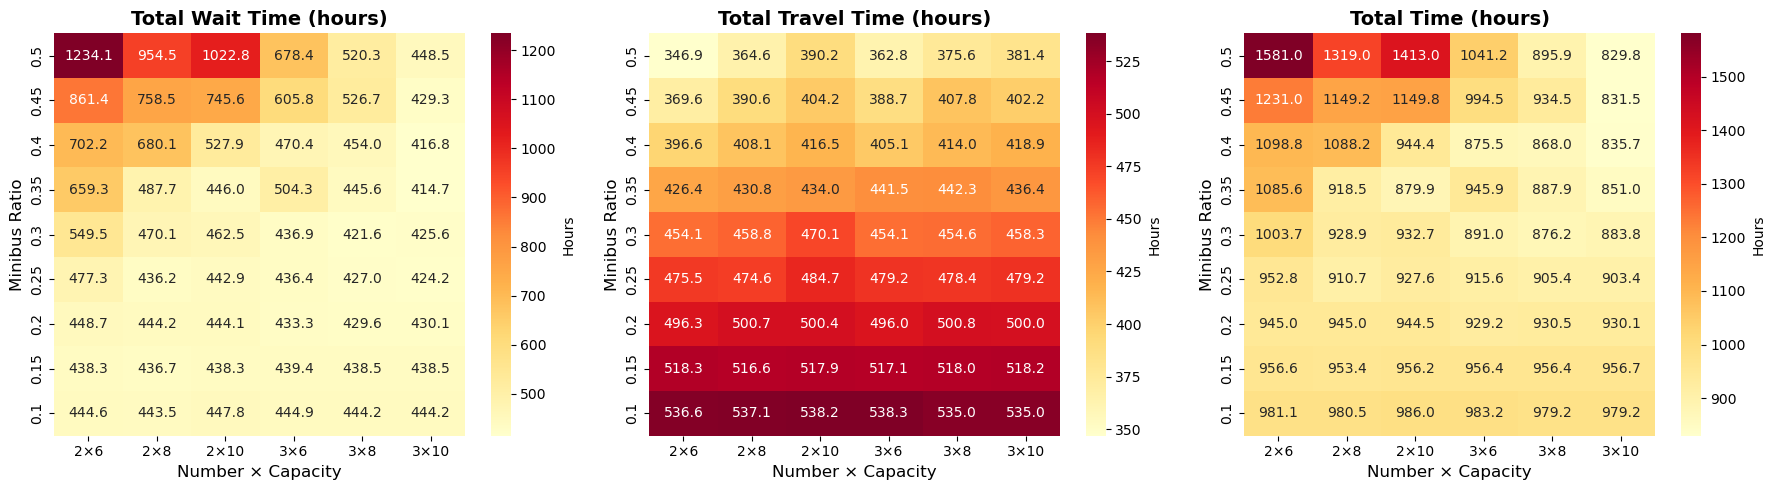

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read CSV file
df = pd.read_csv('Minibus_ratio_results/experiment_summary.csv')

# Create a label column for display
df['capacity_label'] = df['num_minibuses'].astype(str) + '×' + df['minibus_capacity'].astype(str)

# Create a sorting key to control the order (2×6, 2×8, 2×10, 3×6, 3×8, 3×10)
df['sort_key'] = df['num_minibuses'] * 100 + df['minibus_capacity']

print("Unique capacity labels:")
print(df[['num_minibuses', 'minibus_capacity', 'capacity_label', 'sort_key']].drop_duplicates().sort_values('sort_key'))

# Create three heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Prepare data - create pivot tables for each metric
metrics = [
    ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
    ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
    ('total_total_time_hours', 'Total Time (hours)', axes[2])
]

for metric_col, title, ax in metrics:
    # Create pivot table with capacity_label as columns
    pivot_data = df.pivot_table(
        values=metric_col,
        index='minibus_ratio',
        columns='sort_key',
        aggfunc='mean'
    )
    
    # Create mapping from sort_key to display label
    label_mapping = df[['sort_key', 'capacity_label']].drop_duplicates().set_index('sort_key')['capacity_label'].to_dict()
    
    # Rename columns to display labels
    pivot_data.columns = [label_mapping[col] for col in pivot_data.columns]
    
    # Plot heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        ax=ax,
        cbar_kws={'label': 'Hours'}
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Number × Capacity', fontsize=12)
    ax.set_ylabel('Minibus Ratio', fontsize=12)
    
    # Invert y-axis so ratio goes from small to large
    ax.invert_yaxis()

plt.tight_layout()

print("\nHeatmaps generated successfully!")
print(f"\nData Overview:")
print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
print(f"- Total Experiments: {len(df)}")

Found optimization_interval values: [np.int64(5), np.int64(30), np.int64(60), np.int64(600)]

Unique capacity labels:
    num_minibuses  minibus_capacity capacity_label  sort_key
0               2                 6            2×6       206
12              2                 8            2×8       208
24              3                 6            3×6       306
36              3                 8            3×8       308

Creating comparison plots across optimize intervals...

Creating line plots showing trends...

SUMMARY STATISTICS

Data Overview:
- Capacity combinations: ['2×6', '2×8', '3×6', '3×8']
- Minibus Ratios: [np.float64(0.1), np.float64(0.25), np.float64(0.4)]
- Optimize Intervals: [np.int64(5), np.int64(30), np.int64(60), np.int64(600)] seconds
- Total Experiments: 48

----------------------------------------------------------------------
BEST CONFIGURATIONS (lowest values):
----------------------------------------------------------------------

Total Wait Time:
  Value: 287

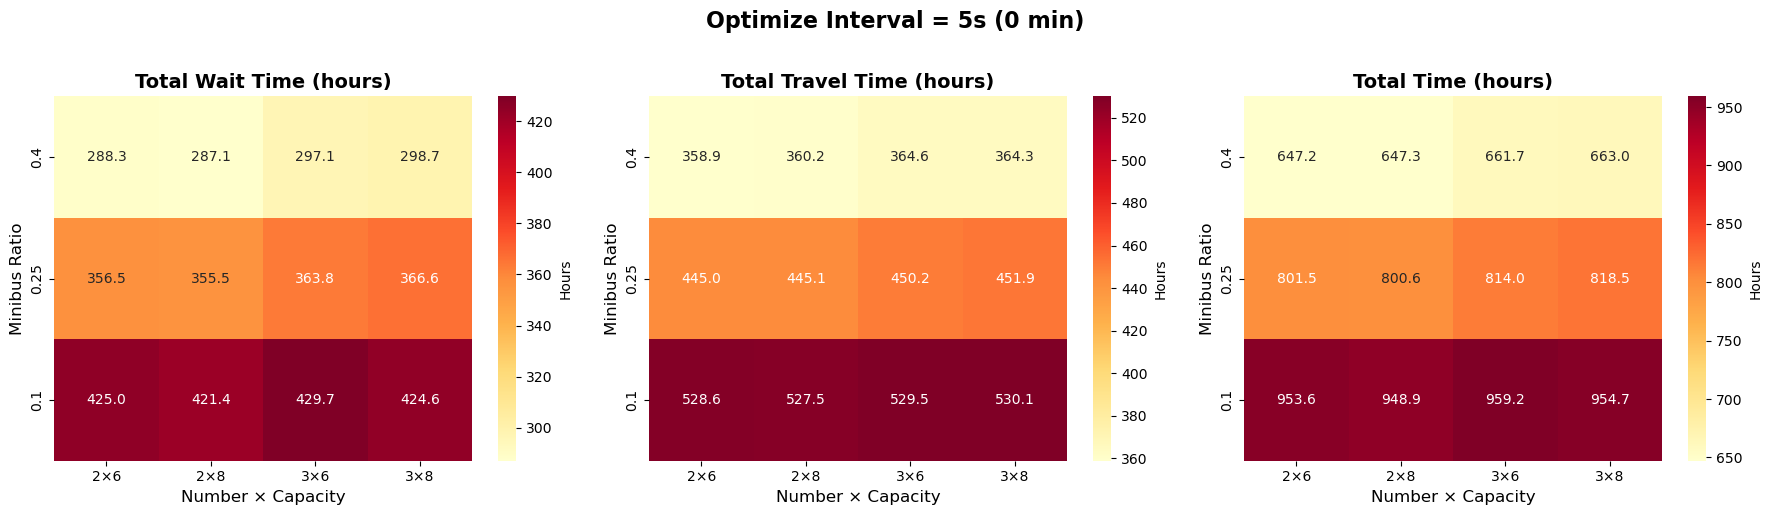

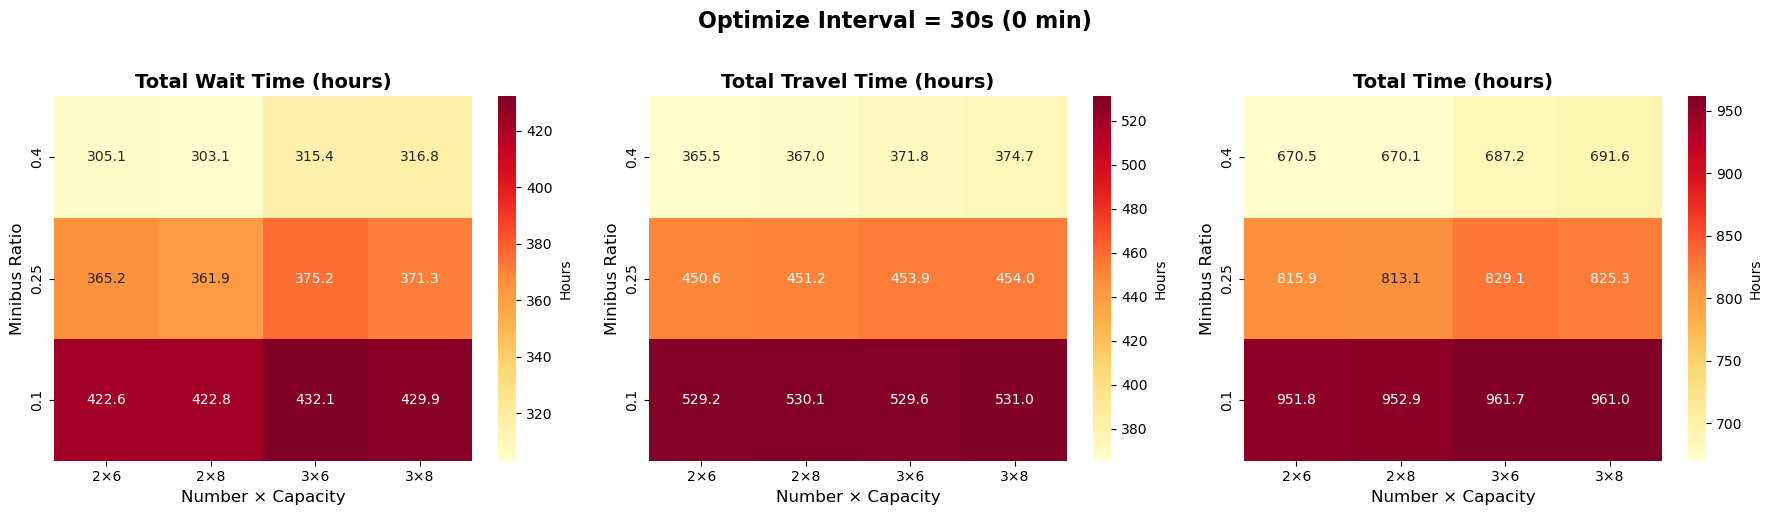

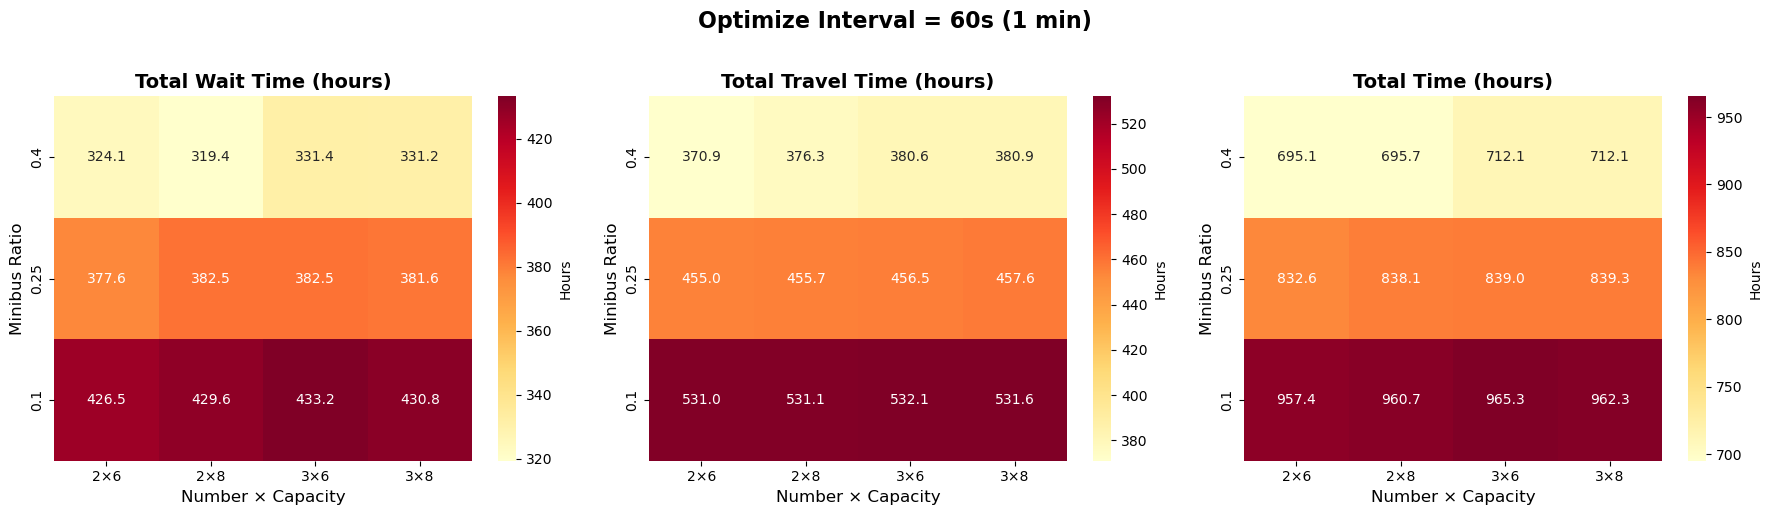

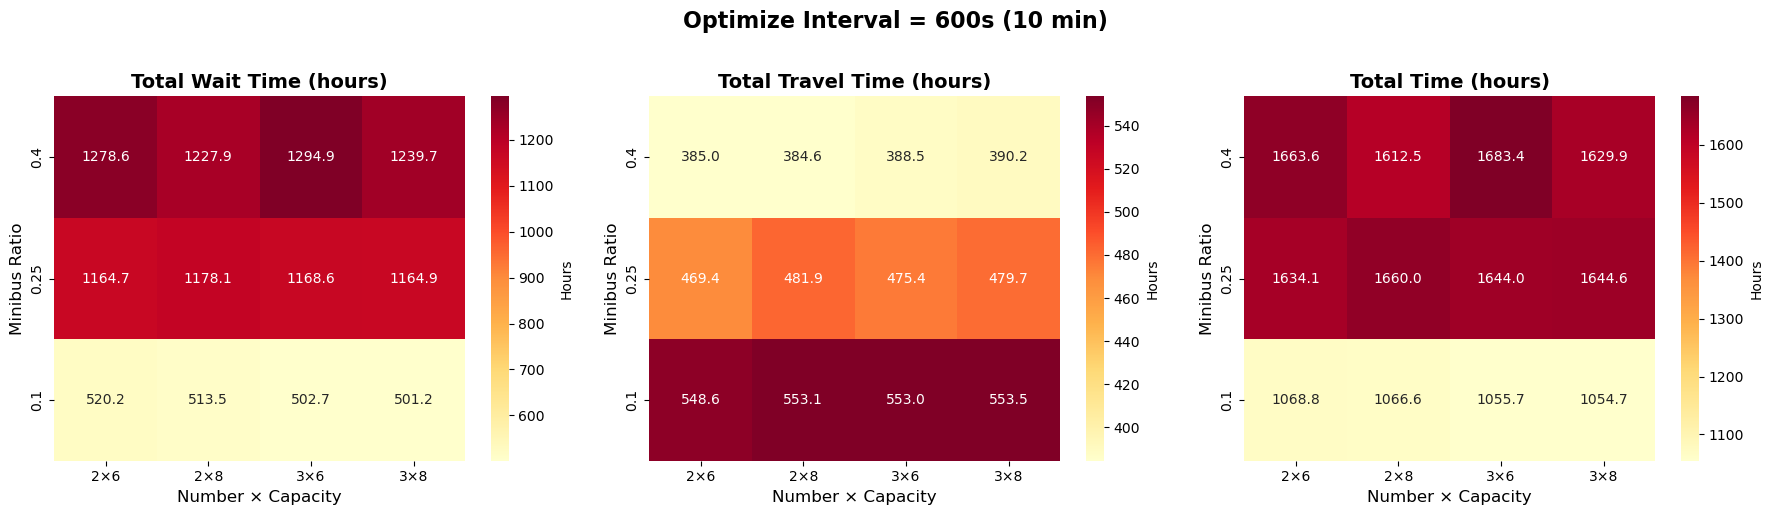

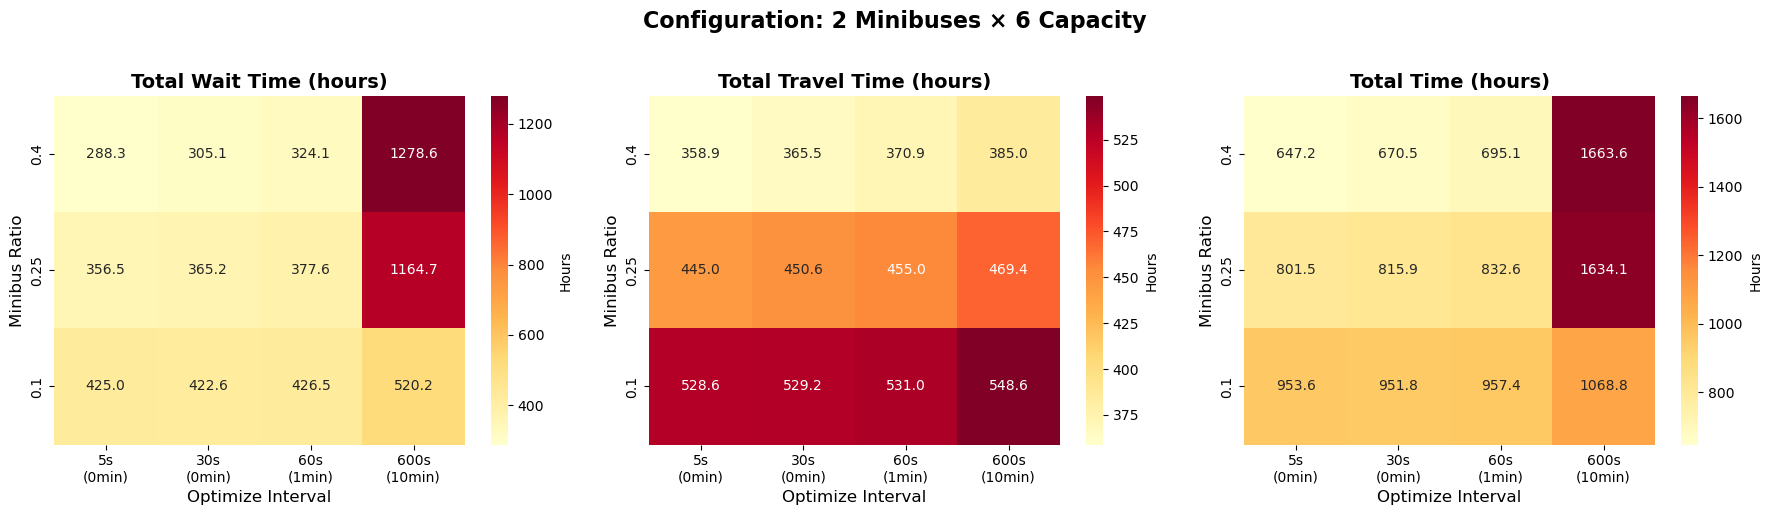

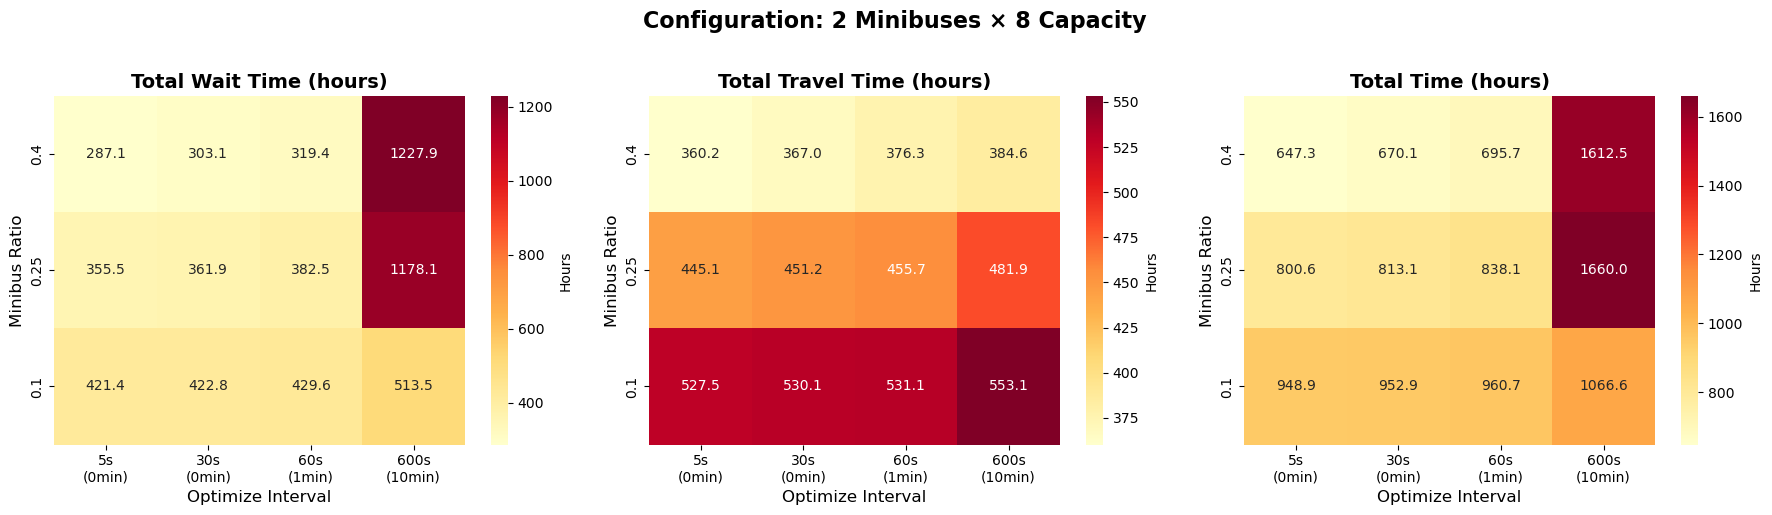

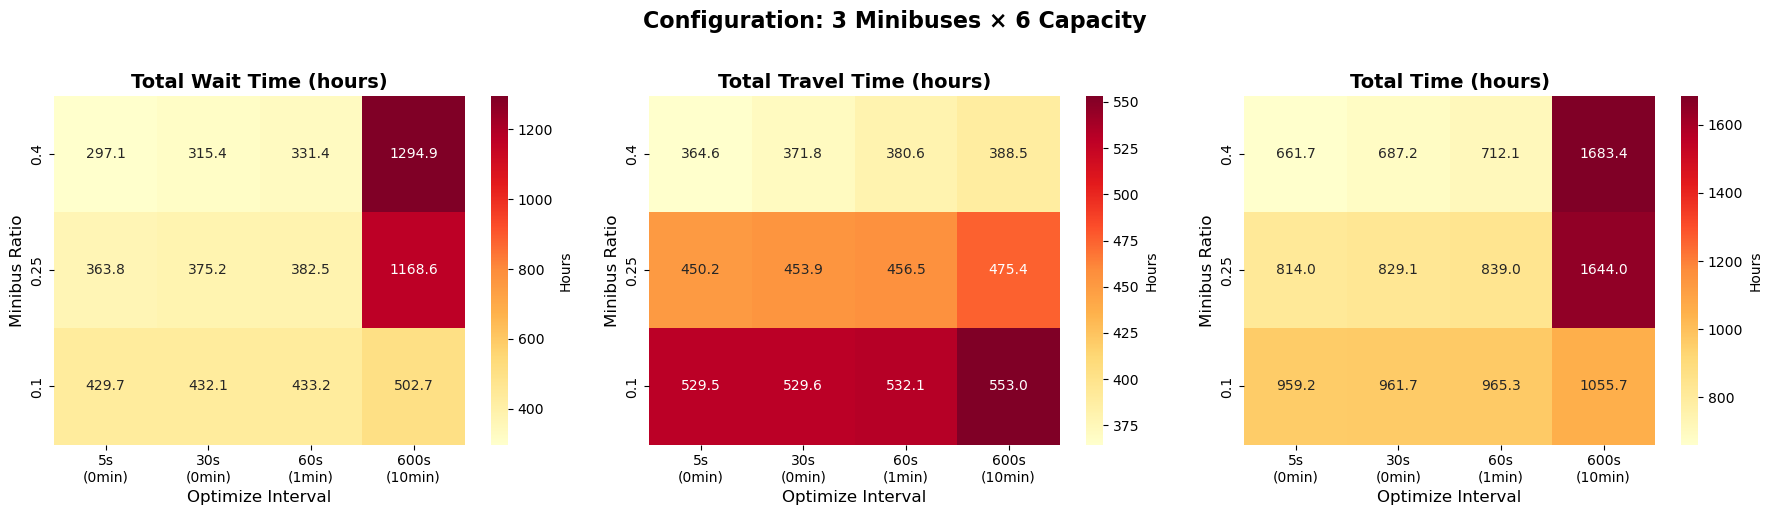

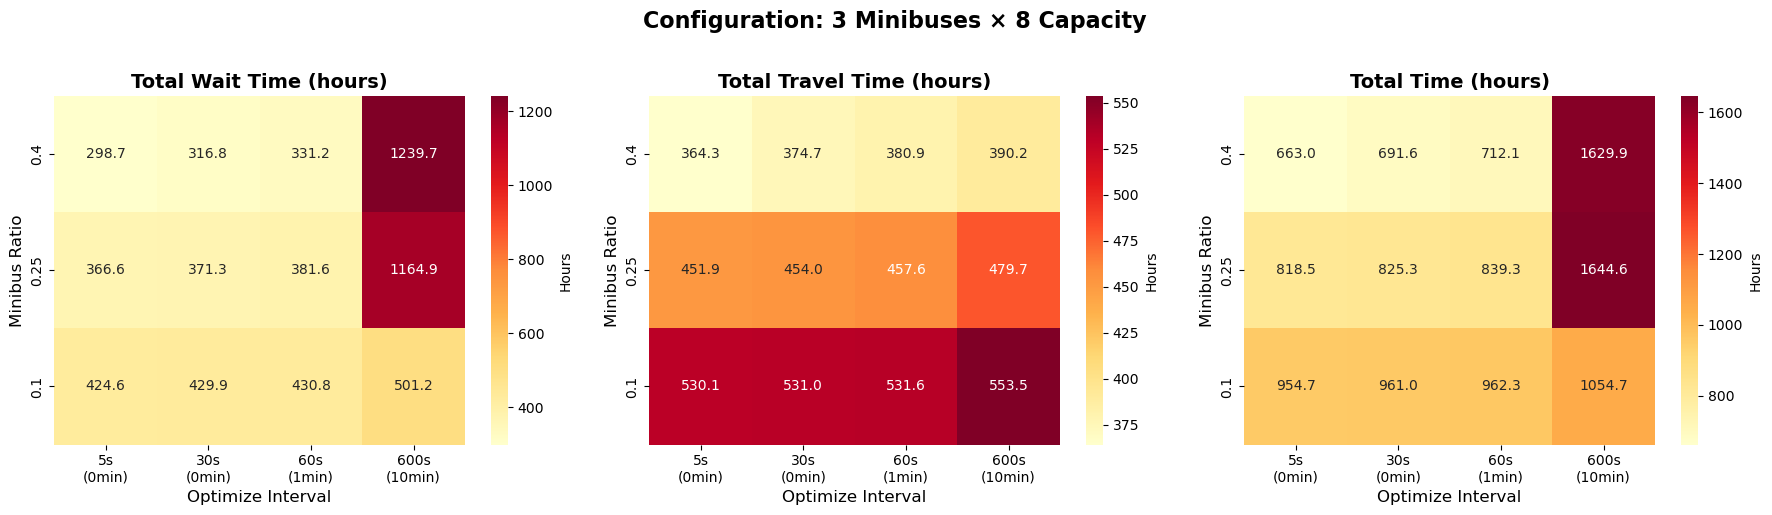

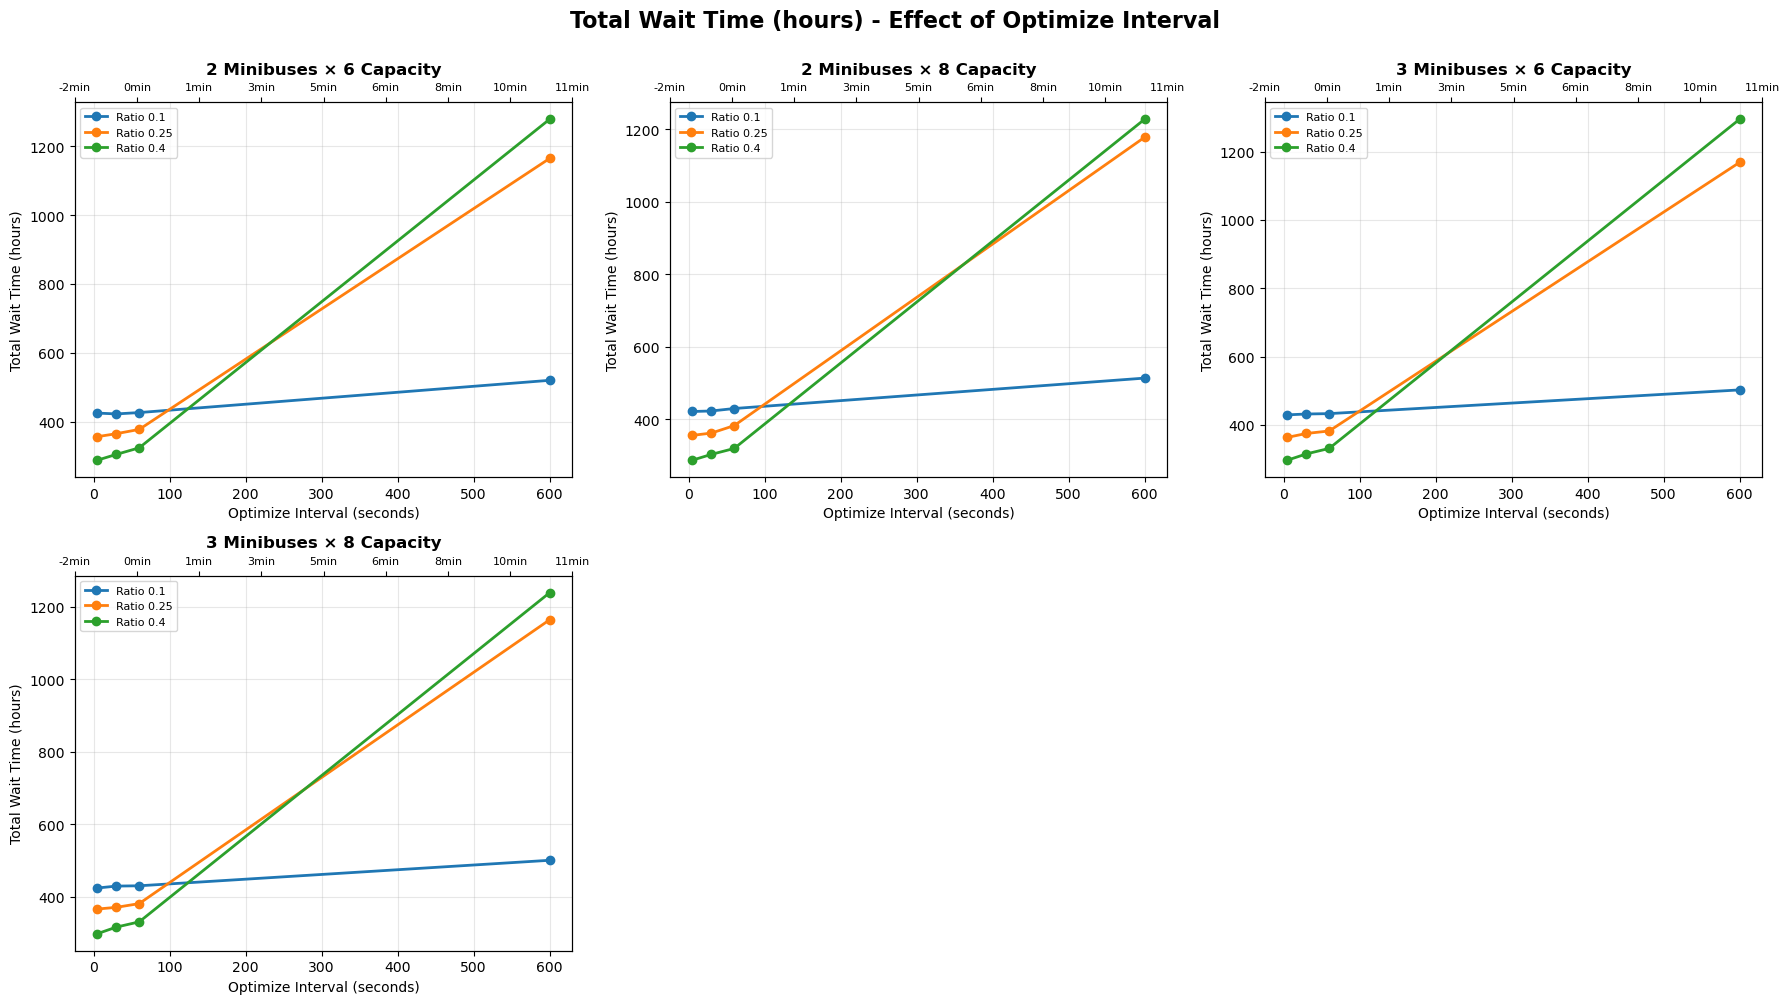

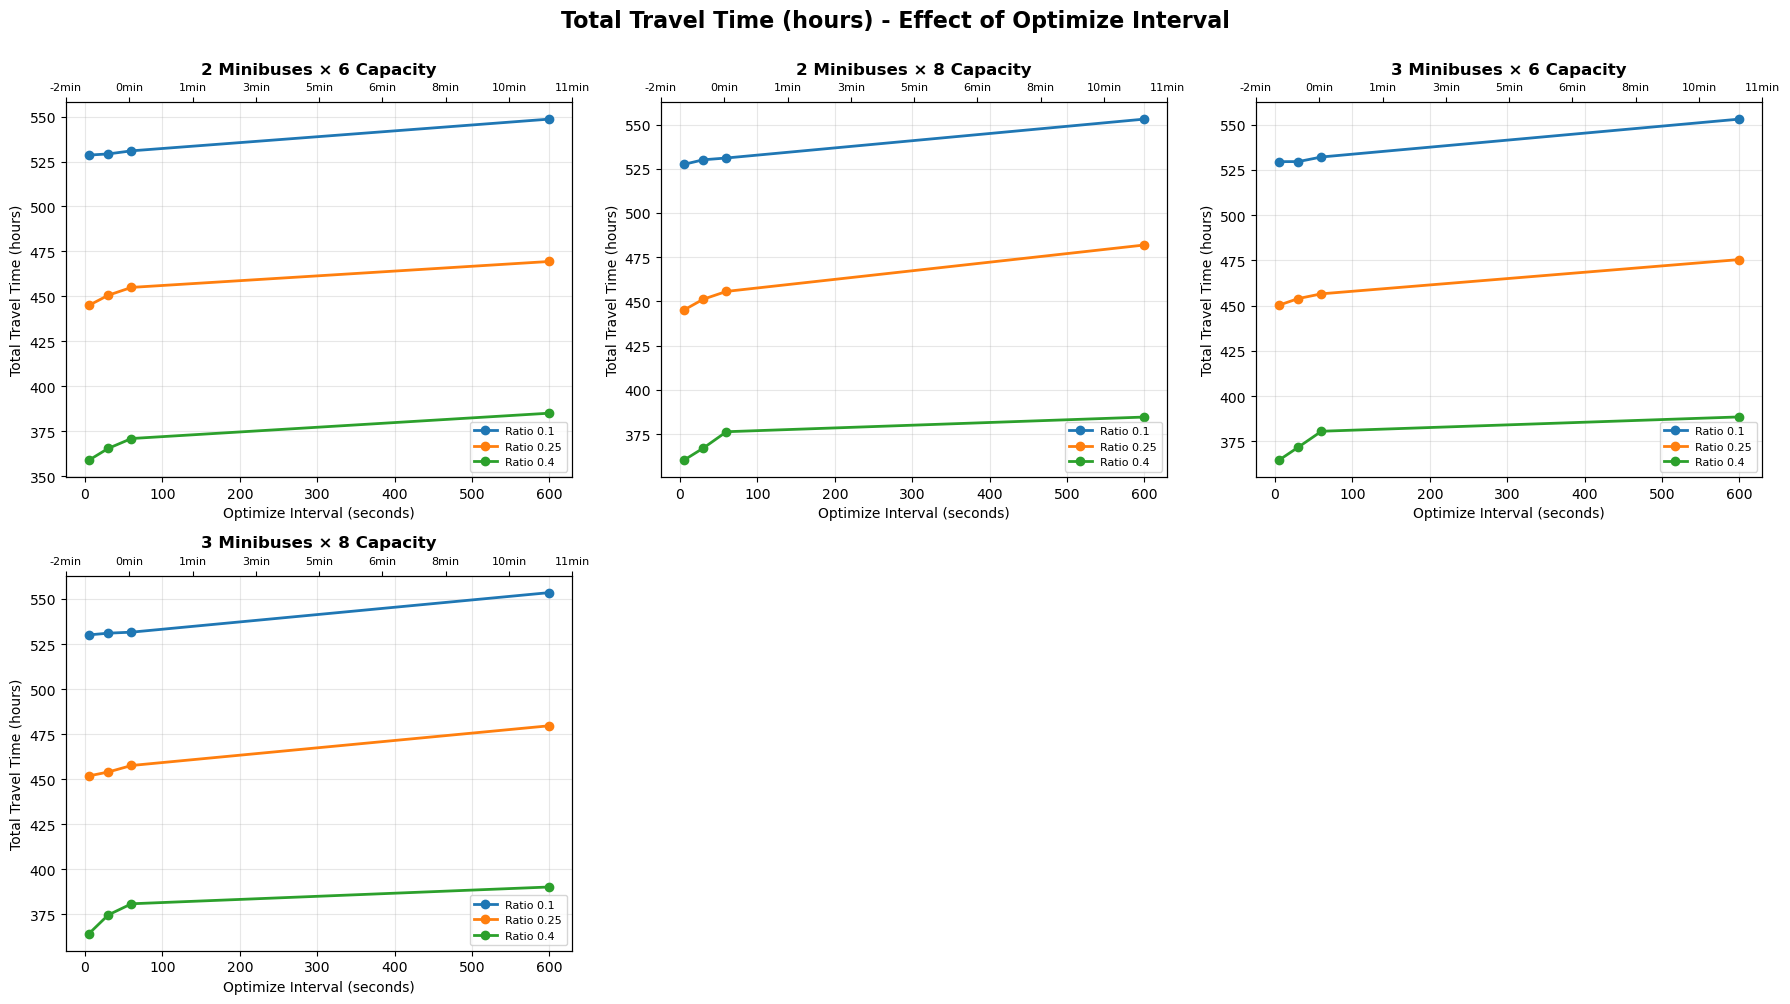

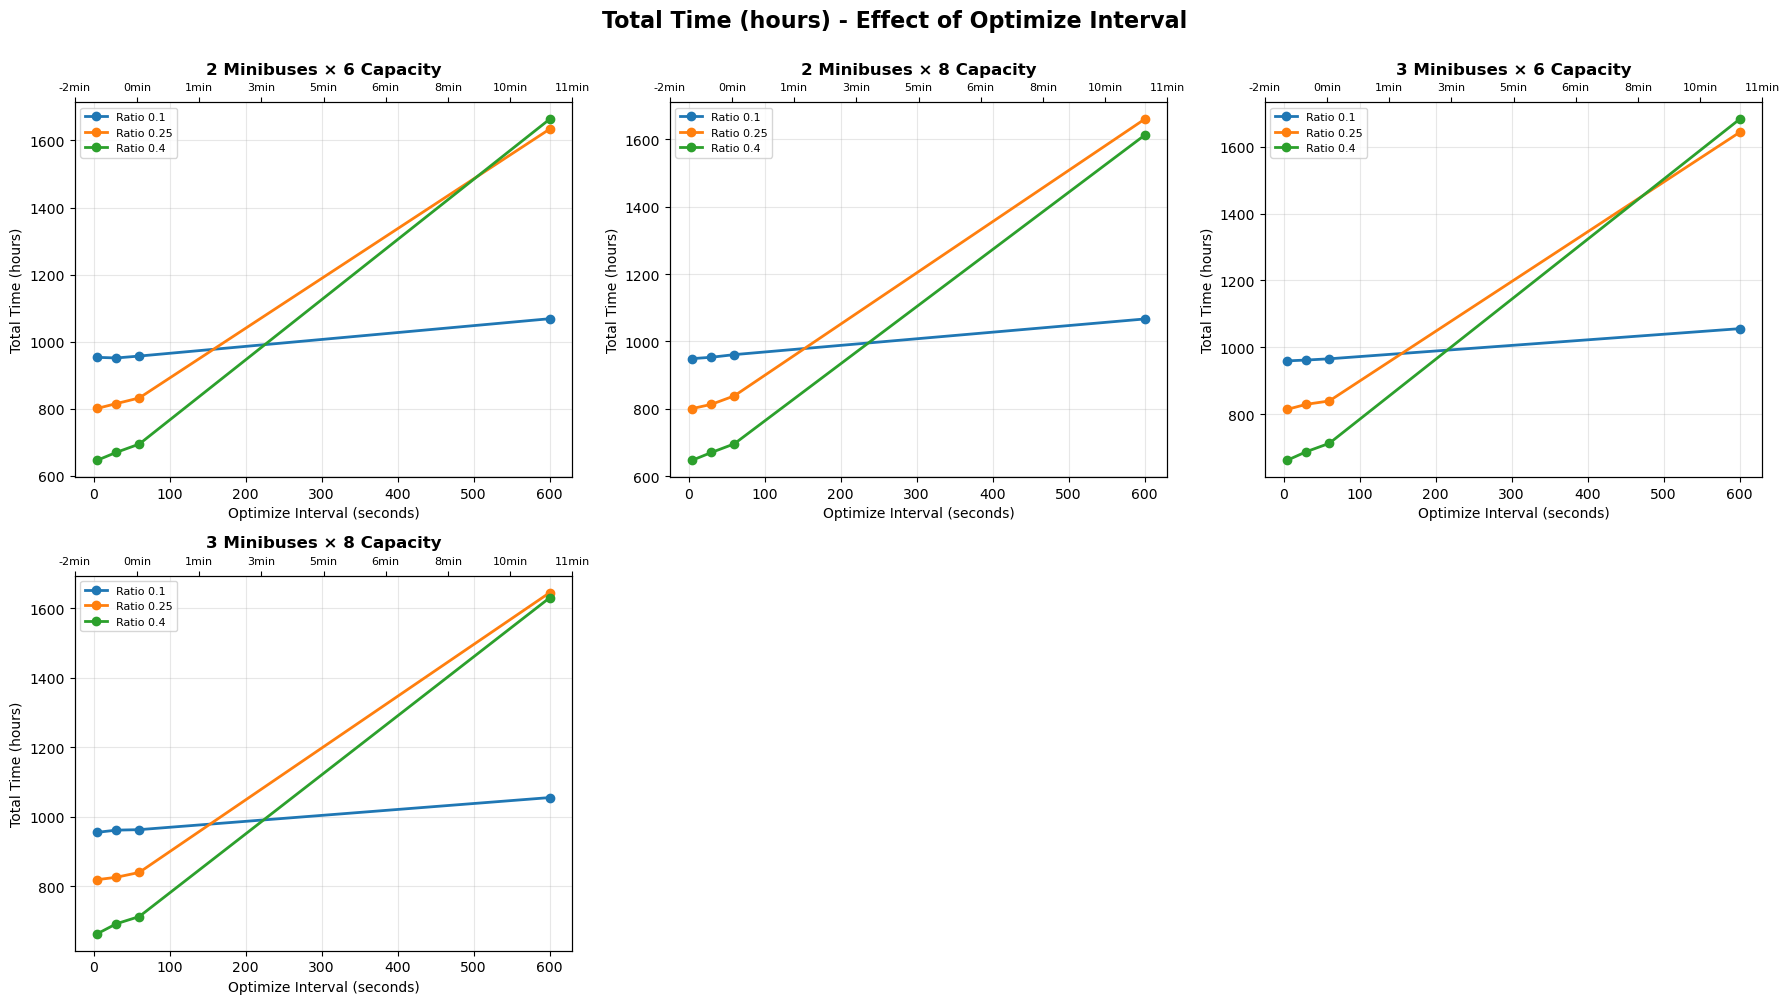

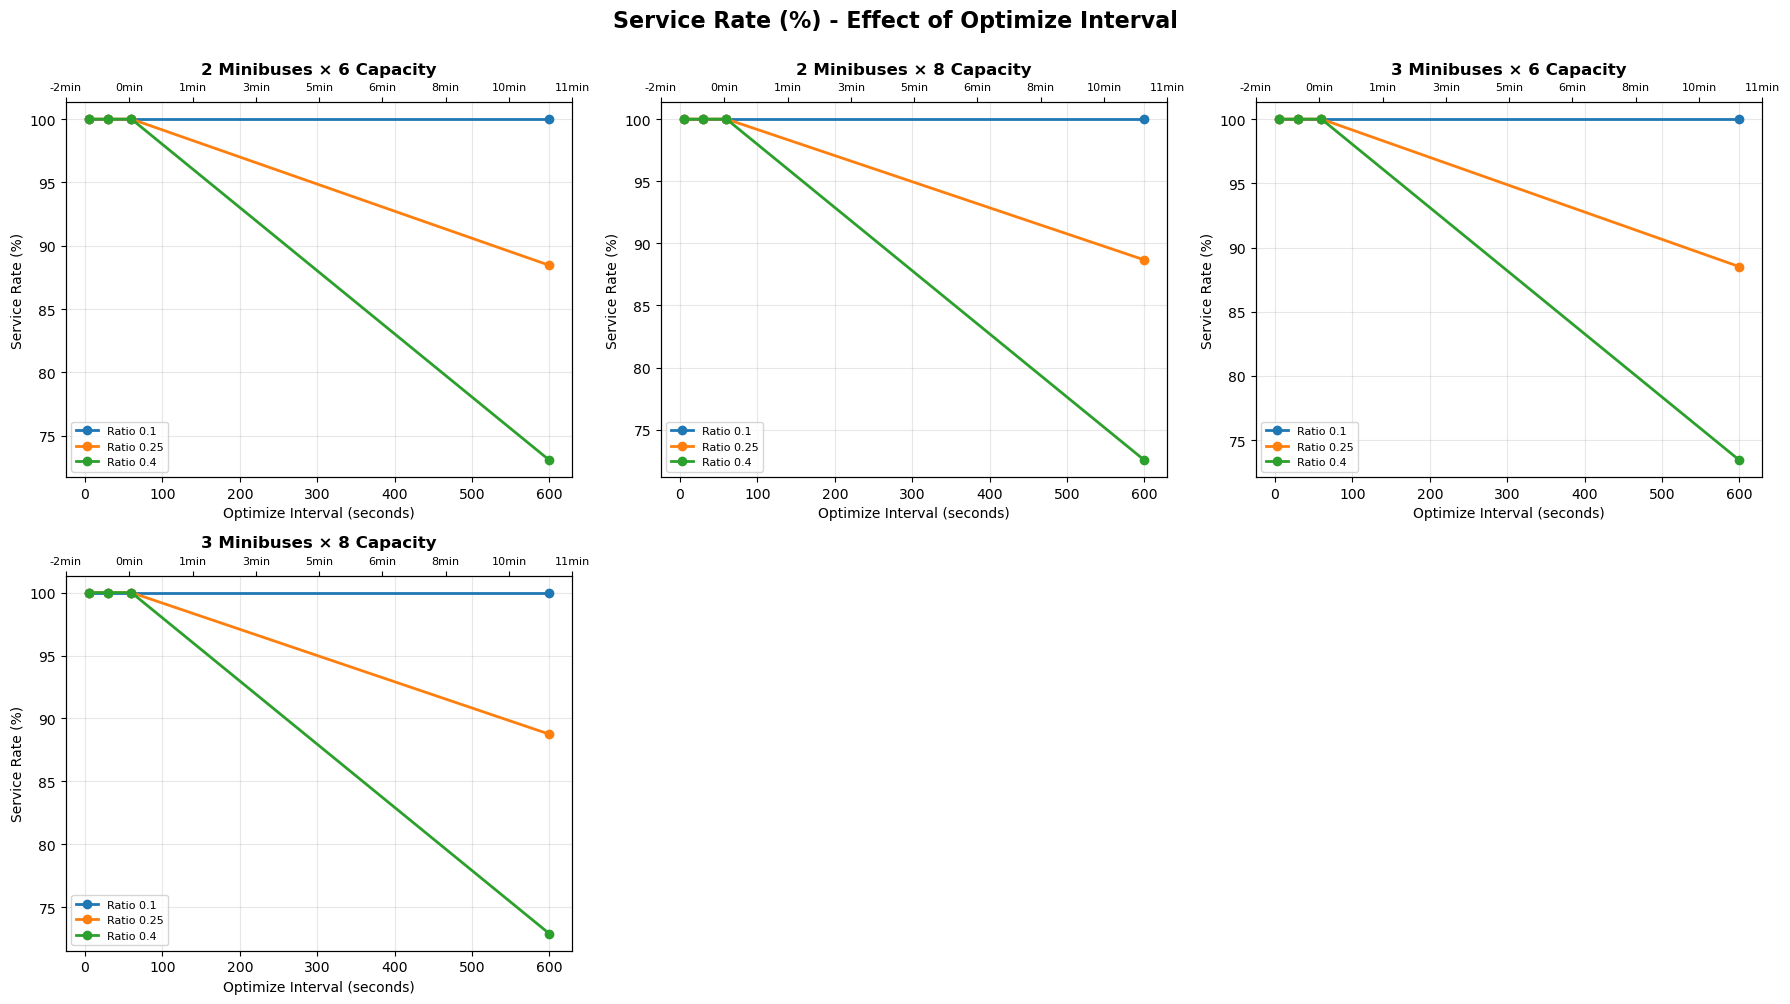

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read CSV file
df = pd.read_csv('Minibus_ratio_results/experiment_summary.csv')

# Check if optimization_interval column exists
if 'optimization_interval' not in df.columns:
    print("Warning: 'optimization_interval' column not found. Using original visualization.")
    has_optimize_interval = False
else:
    has_optimize_interval = True
    print(f"Found optimization_interval values: {sorted(df['optimization_interval'].unique())}")

# Create a label column for display
df['capacity_label'] = df['num_minibuses'].astype(str) + '×' + df['minibus_capacity'].astype(str)

# Create a sorting key to control the order (2×6, 2×8, 2×10, 3×6, 3×8, 3×10)
df['sort_key'] = df['num_minibuses'] * 100 + df['minibus_capacity']

print("\nUnique capacity labels:")
print(df[['num_minibuses', 'minibus_capacity', 'capacity_label', 'sort_key']].drop_duplicates().sort_values('sort_key'))

# ============================================================================
# OPTION 1: Separate plots for each optimization_interval
# ============================================================================
if has_optimize_interval:
    optimize_intervals = sorted(df['optimization_interval'].unique())
    
    for opt_interval in optimize_intervals:
        # Filter data for this optimization_interval
        df_filtered = df[df['optimization_interval'] == opt_interval]
        
        # Create three heatmaps
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Optimize Interval = {opt_interval}s ({opt_interval//60} min)', 
                     fontsize=16, fontweight='bold', y=1.02)
        
        # Prepare data - create pivot tables for each metric
        metrics = [
            ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
            ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
            ('total_total_time_hours', 'Total Time (hours)', axes[2])
        ]
        
        for metric_col, title, ax in metrics:
            # Create pivot table with capacity_label as columns
            pivot_data = df_filtered.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='sort_key',
                aggfunc='mean'
            )
            
            # Create mapping from sort_key to display label
            label_mapping = df_filtered[['sort_key', 'capacity_label']].drop_duplicates().set_index('sort_key')['capacity_label'].to_dict()
            
            # Rename columns to display labels
            pivot_data.columns = [label_mapping[col] for col in pivot_data.columns]
            
            # Plot heatmap
            sns.heatmap(
                pivot_data,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Hours'}
            )
            
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.set_xlabel('Number × Capacity', fontsize=12)
            ax.set_ylabel('Minibus Ratio', fontsize=12)
            
            # Invert y-axis so ratio goes from small to large
            ax.invert_yaxis()
        
        plt.tight_layout()
        # plt.savefig(f'heatmap_opt_{opt_interval}s.png', dpi=300, bbox_inches='tight')
        # print(f"\nSaved: heatmap_opt_{opt_interval}s.png")

# ============================================================================
# OPTION 2: Combined comparison plots showing effect of optimization_interval
# ============================================================================
if has_optimize_interval:
    print("\n" + "="*70)
    print("Creating comparison plots across optimize intervals...")
    print("="*70)
    
    # For each capacity configuration, show how metrics vary with optimization_interval and ratio
    capacity_configs = df.groupby(['num_minibuses', 'minibus_capacity']).size().index.tolist()
    
    for num_minibuses, capacity in capacity_configs:
        df_config = df[(df['num_minibuses'] == num_minibuses) & 
                       (df['minibus_capacity'] == capacity)]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Configuration: {num_minibuses} Minibuses × {capacity} Capacity', 
                     fontsize=16, fontweight='bold', y=1.02)
        
        metrics = [
            ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
            ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
            ('total_total_time_hours', 'Total Time (hours)', axes[2])
        ]
        
        for metric_col, title, ax in metrics:
            # Create pivot table: ratio vs optimization_interval
            pivot_data = df_config.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='optimization_interval',
                aggfunc='mean'
            )
            
            # Rename columns to show minutes
            pivot_data.columns = [f'{int(col)}s\n({int(col//60)}min)' for col in pivot_data.columns]
            
            # Plot heatmap
            sns.heatmap(
                pivot_data,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Hours'}
            )
            
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=12)
            ax.set_ylabel('Minibus Ratio', fontsize=12)
            
            # Invert y-axis so ratio goes from small to large
            ax.invert_yaxis()
        
        plt.tight_layout()
        filename = f'comparison_n{num_minibuses}_c{capacity}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# OPTION 3: Line plots showing trends
# ============================================================================
if has_optimize_interval:
    print("\n" + "="*70)
    print("Creating line plots showing trends...")
    print("="*70)
    
    # Create line plots for each metric
    metrics_to_plot = [
        ('total_wait_time_hours', 'Total Wait Time (hours)'),
        ('total_travel_time_hours', 'Total Travel Time (hours)'),
        ('total_total_time_hours', 'Total Time (hours)'),
        ('service_rate', 'Service Rate (%)')
    ]
    
    for metric_col, metric_name in metrics_to_plot:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'{metric_name} - Effect of Optimize Interval', 
                     fontsize=16, fontweight='bold', y=1.00)
        axes = axes.flatten()
        
        # For each capacity configuration
        for idx, (num_minibuses, capacity) in enumerate(capacity_configs):
            if idx >= len(axes):
                break
                
            ax = axes[idx]
            df_config = df[(df['num_minibuses'] == num_minibuses) & 
                           (df['minibus_capacity'] == capacity)]
            
            # Plot lines for each minibus_ratio
            for ratio in sorted(df_config['minibus_ratio'].unique()):
                df_ratio = df_config[df_config['minibus_ratio'] == ratio]
                df_ratio_sorted = df_ratio.sort_values('optimization_interval')
                
                ax.plot(df_ratio_sorted['optimization_interval'], 
                       df_ratio_sorted[metric_col],
                       marker='o', 
                       label=f'Ratio {ratio}',
                       linewidth=2,
                       markersize=6)
            
            ax.set_title(f'{num_minibuses} Minibuses × {capacity} Capacity', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval (seconds)', fontsize=10)
            ax.set_ylabel(metric_name, fontsize=10)
            ax.legend(loc='best', fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Add secondary x-axis showing minutes
            ax2 = ax.twiny()
            ax2.set_xlim(ax.get_xlim())
            ax2.set_xticks(ax.get_xticks())
            ax2.set_xticklabels([f'{int(x//60)}min' for x in ax.get_xticks()], fontsize=8)
        
        # Hide unused subplots
        for idx in range(len(capacity_configs), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        filename = f'lineplot_{metric_col}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

if has_optimize_interval:
    print(f"\nData Overview:")
    print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
    print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
    print(f"- Optimize Intervals: {sorted(df['optimization_interval'].unique())} seconds")
    print(f"- Total Experiments: {len(df)}")
    
    # Find best configurations for each metric
    print("\n" + "-"*70)
    print("BEST CONFIGURATIONS (lowest values):")
    print("-"*70)
    
    for metric_col, metric_name in [
        ('total_wait_time_hours', 'Total Wait Time'),
        ('total_travel_time_hours', 'Total Travel Time'),
        ('total_total_time_hours', 'Total Time')
    ]:
        best_row = df.loc[df[metric_col].idxmin()]
        print(f"\n{metric_name}:")
        print(f"  Value: {best_row[metric_col]:.2f} hours")
        print(f"  Configuration: {int(best_row['num_minibuses'])} minibuses × {int(best_row['minibus_capacity'])} capacity")
        print(f"  Ratio: {best_row['minibus_ratio']:.2f}")
        print(f"  Optimize Interval: {int(best_row['optimization_interval'])}s ({int(best_row['optimization_interval']//60)} min)")
    
    # Best service rate
    best_row = df.loc[df['service_rate'].idxmax()]
    print(f"\nService Rate (highest):")
    print(f"  Value: {best_row['service_rate']:.2f}%")
    print(f"  Configuration: {int(best_row['num_minibuses'])} minibuses × {int(best_row['minibus_capacity'])} capacity")
    print(f"  Ratio: {best_row['minibus_ratio']:.2f}")
    print(f"  Optimize Interval: {int(best_row['optimization_interval'])}s ({int(best_row['optimization_interval']//60)} min)")
    
    # Effect of optimization_interval
    print("\n" + "-"*70)
    print("EFFECT OF OPTIMIZE INTERVAL (averaged across all configs):")
    print("-"*70)
    
    interval_stats = df.groupby('optimization_interval').agg({
        'total_wait_time_hours': 'mean',
        'total_travel_time_hours': 'mean',
        'total_total_time_hours': 'mean',
        'service_rate': 'mean'
    }).round(2)
    
    print("\n" + interval_stats.to_string())

else:
    # Original summary for data without optimization_interval
    print(f"\nData Overview:")
    print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
    print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
    print(f"- Total Experiments: {len(df)}")

print("\n" + "="*70)
print("All visualizations generated successfully!")
print("="*70)

Found optimization_interval values: [np.int64(30), np.int64(60), np.int64(120)]
Found vehicle-specific total time columns!

Unique capacity labels:
    num_minibuses  minibus_capacity capacity_label  sort_key
0               2                 6            2×6       206
9               2                 8            2×8       208
18              3                 6            3×6       306
27              3                 8            3×8       308

Creating comparison plots across optimize intervals...

Creating line plots showing trends...

Creating Bus vs Minibus comparison plots...


/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_11941/4063294101.py:333: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_config['time_difference'] = df_config['bus_total_total_time_hours'] - df_config['minibus_total_total_time_hours']
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_11941/4063294101.py:333: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_config['time_difference'] = df_config['bus_total_total_time_hours'] - df_config['minibus_total_total_time_hours']
/var/folders/58/tx


Creating average time per passenger comparison...


/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_11941/4063294101.py:409: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))



SUMMARY STATISTICS

Data Overview:
- Capacity combinations: ['2×6', '2×8', '3×6', '3×8']
- Minibus Ratios: [np.float64(0.1), np.float64(0.2), np.float64(0.3)]
- Optimize Intervals: [np.int64(30), np.int64(60), np.int64(120)] seconds
- Total Experiments: 36

----------------------------------------------------------------------
BEST CONFIGURATIONS (lowest values):
----------------------------------------------------------------------

Total Wait Time:
  Value: 345.98 hours
  Configuration: 2 minibuses × 8 capacity
  Ratio: 0.30
  Optimize Interval: 30s (0 min)

Total Travel Time:
  Value: 421.72 hours
  Configuration: 2 minibuses × 6 capacity
  Ratio: 0.30
  Optimize Interval: 30s (0 min)

Total Time - All:
  Value: 768.20 hours
  Configuration: 2 minibuses × 8 capacity
  Ratio: 0.30
  Optimize Interval: 30s (0 min)

Total Time - Bus Only:
  Value: 725.12 hours
  Configuration: 2 minibuses × 6 capacity
  Ratio: 0.30
  Optimize Interval: 30s (0 min)

Total Time - Minibus Only:
  Value: 

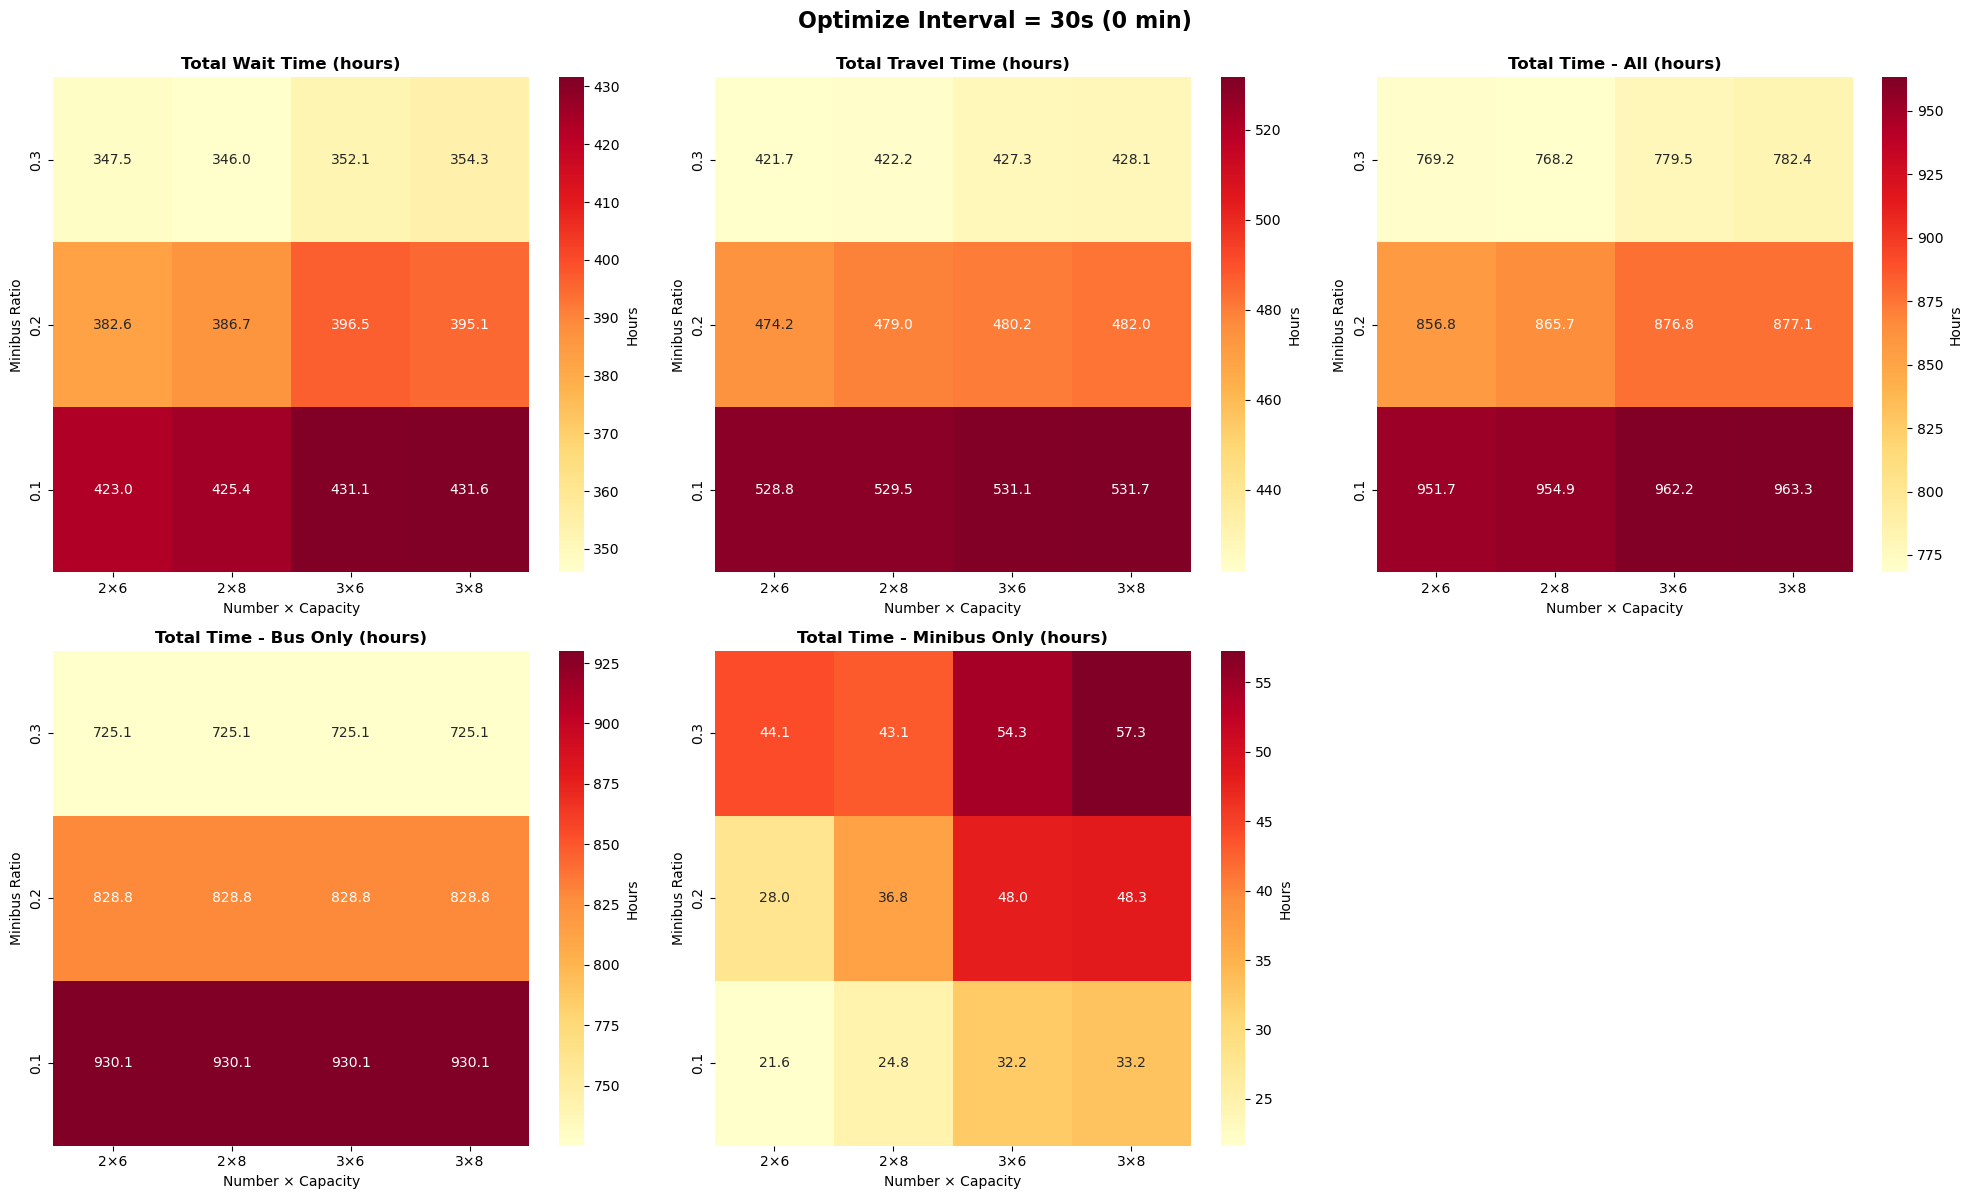

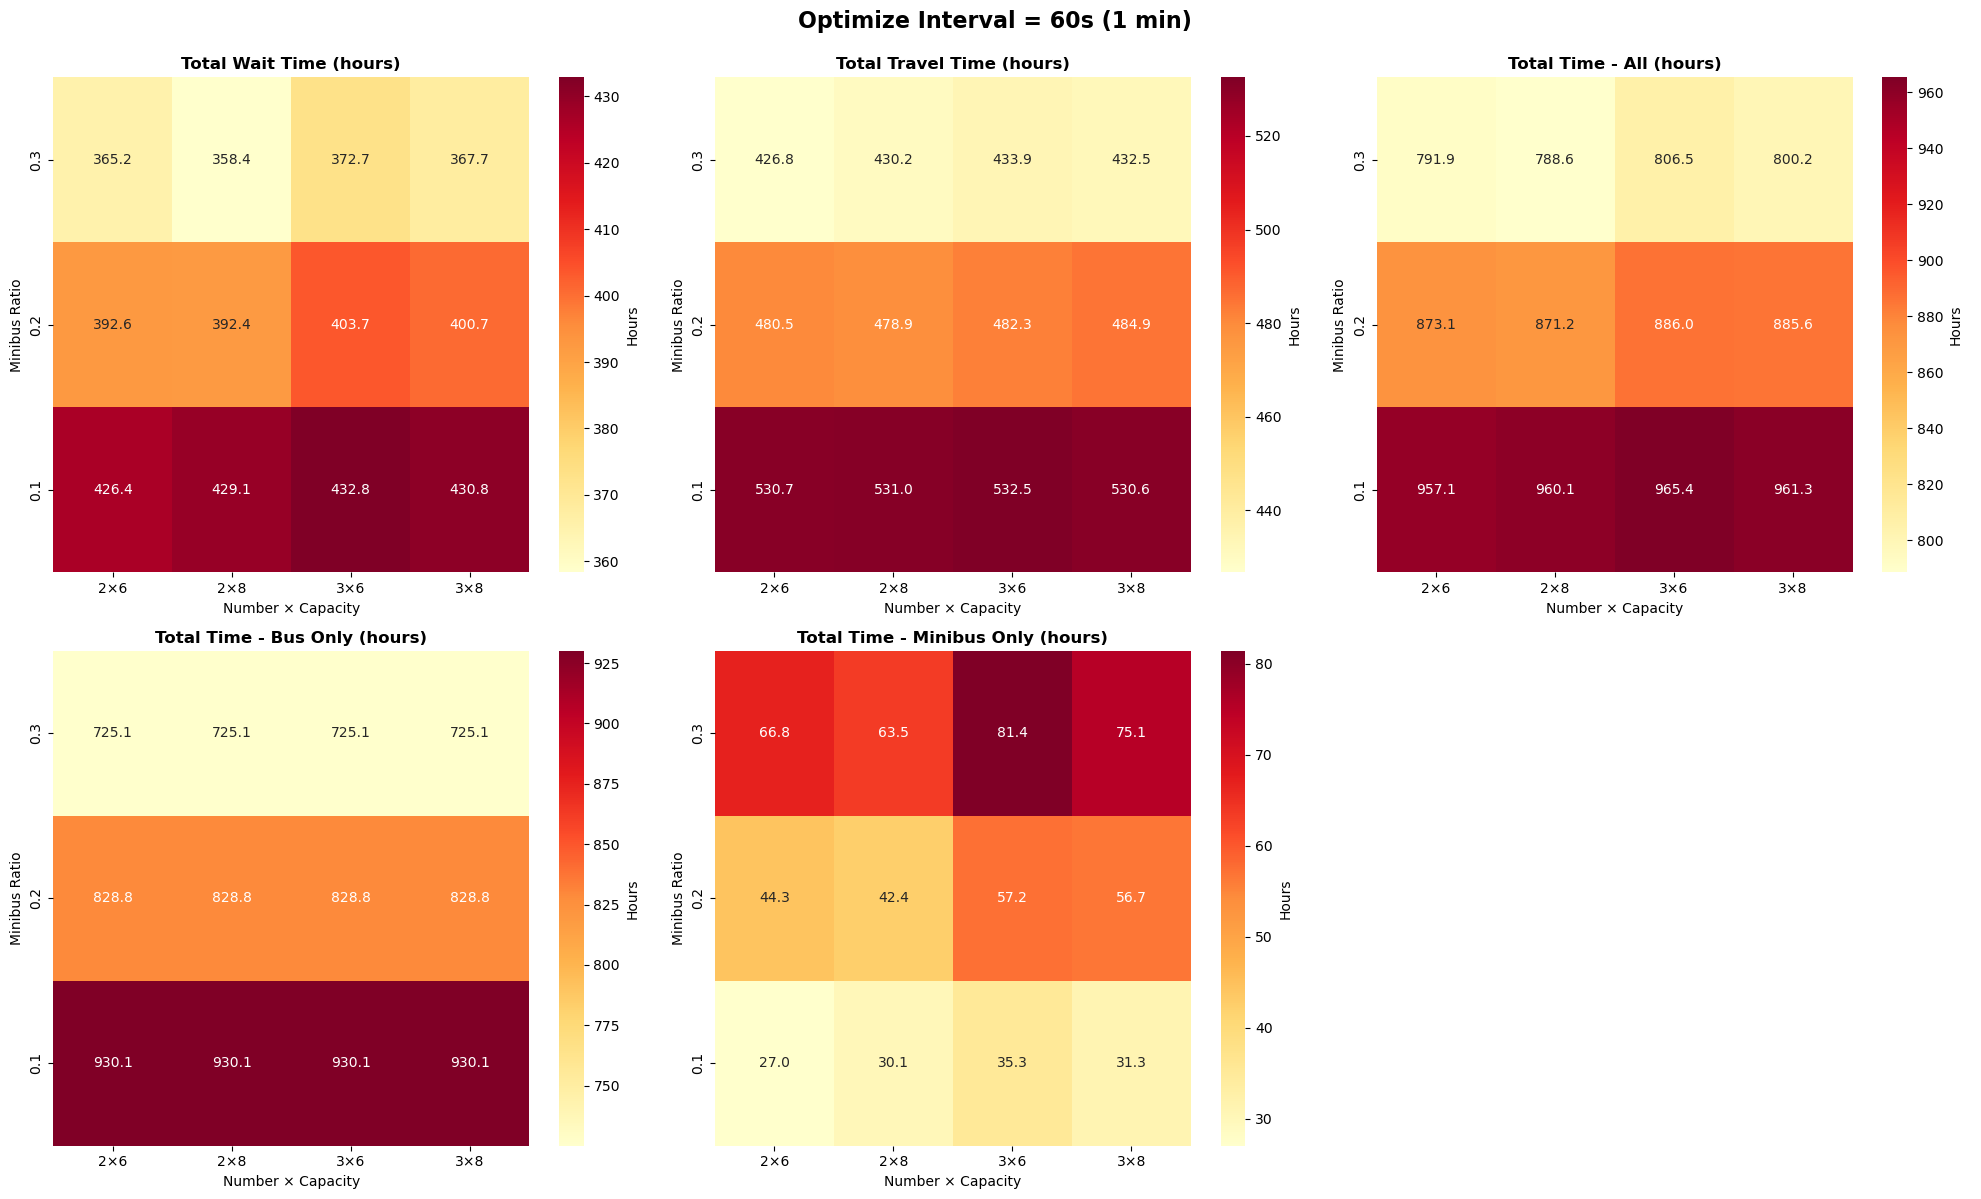

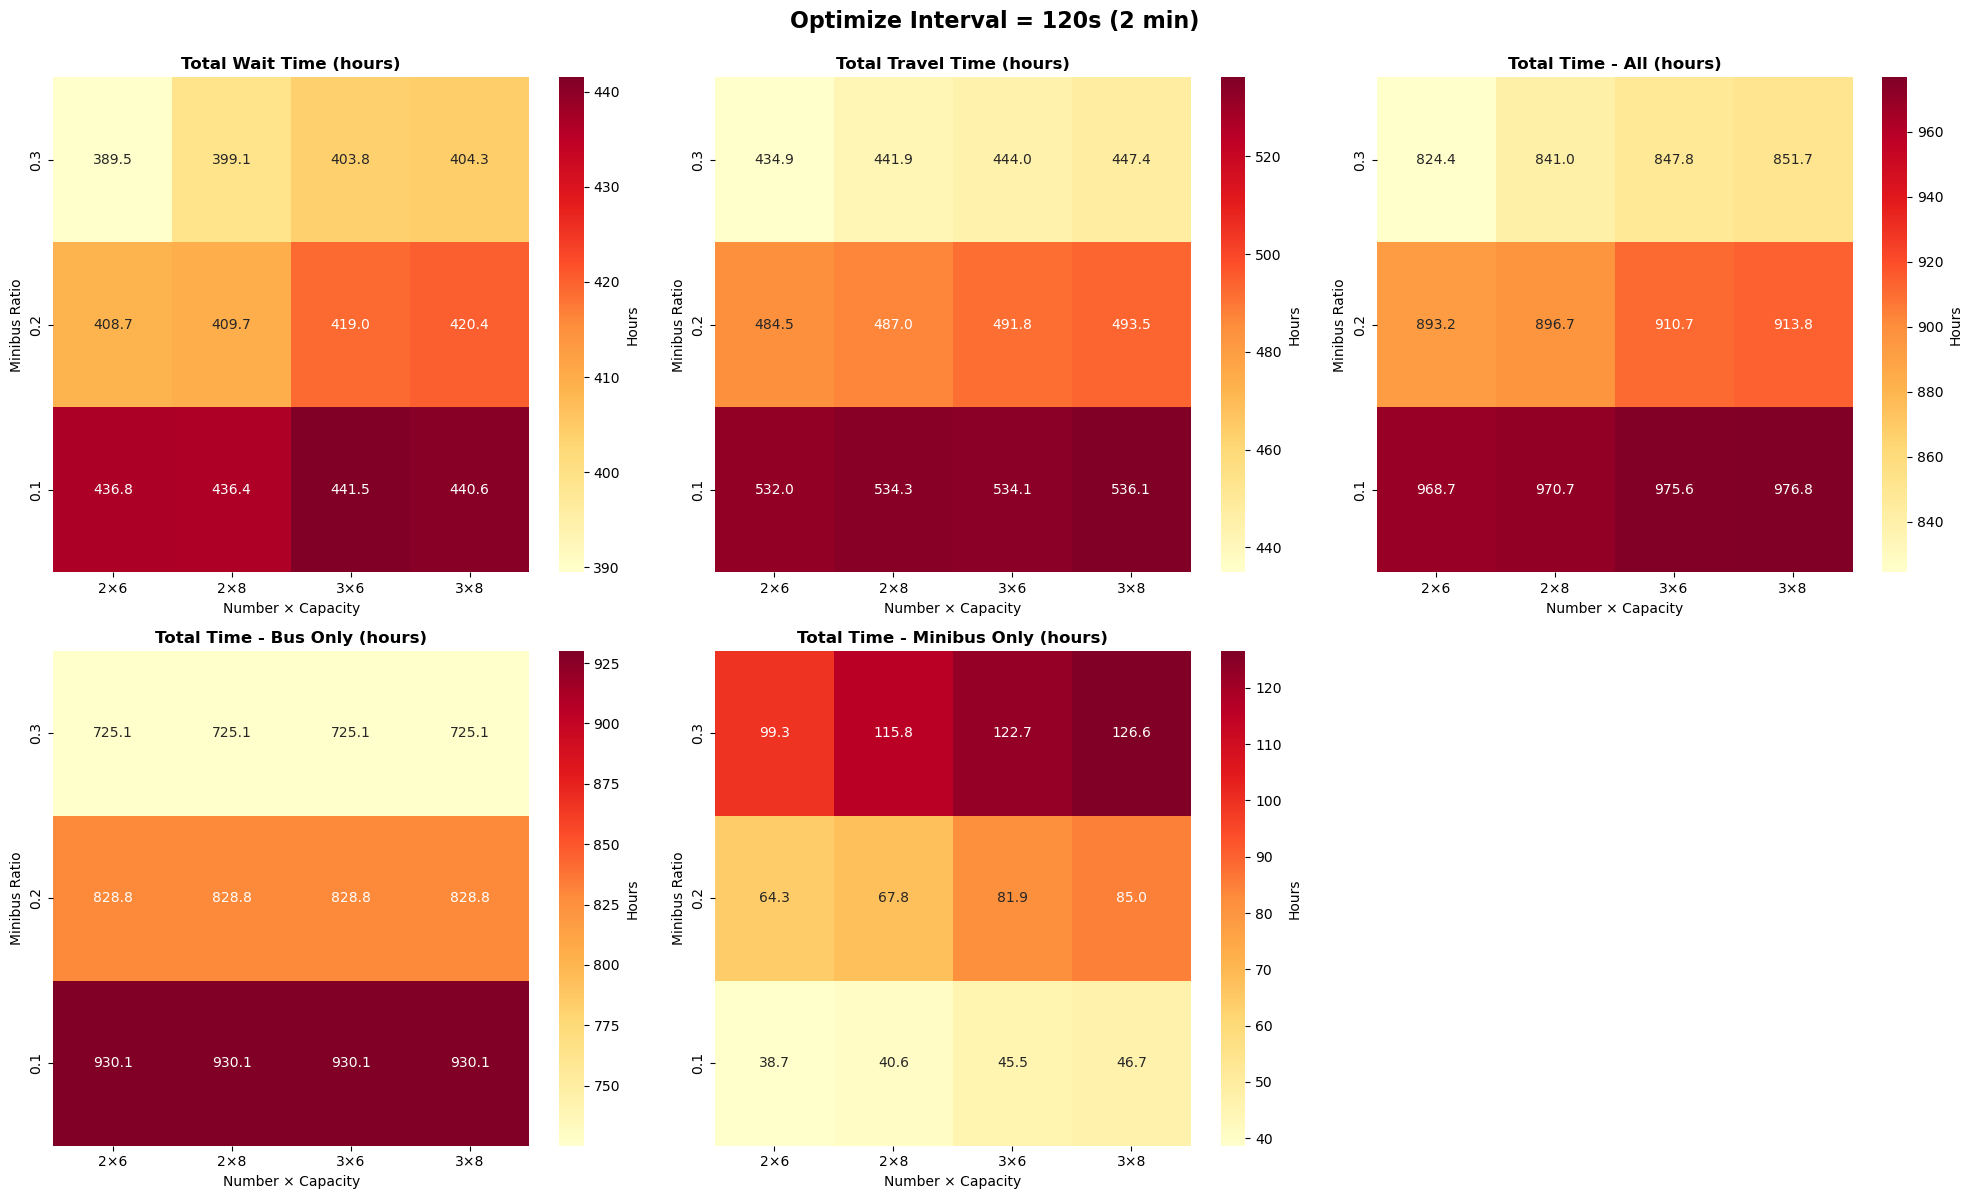

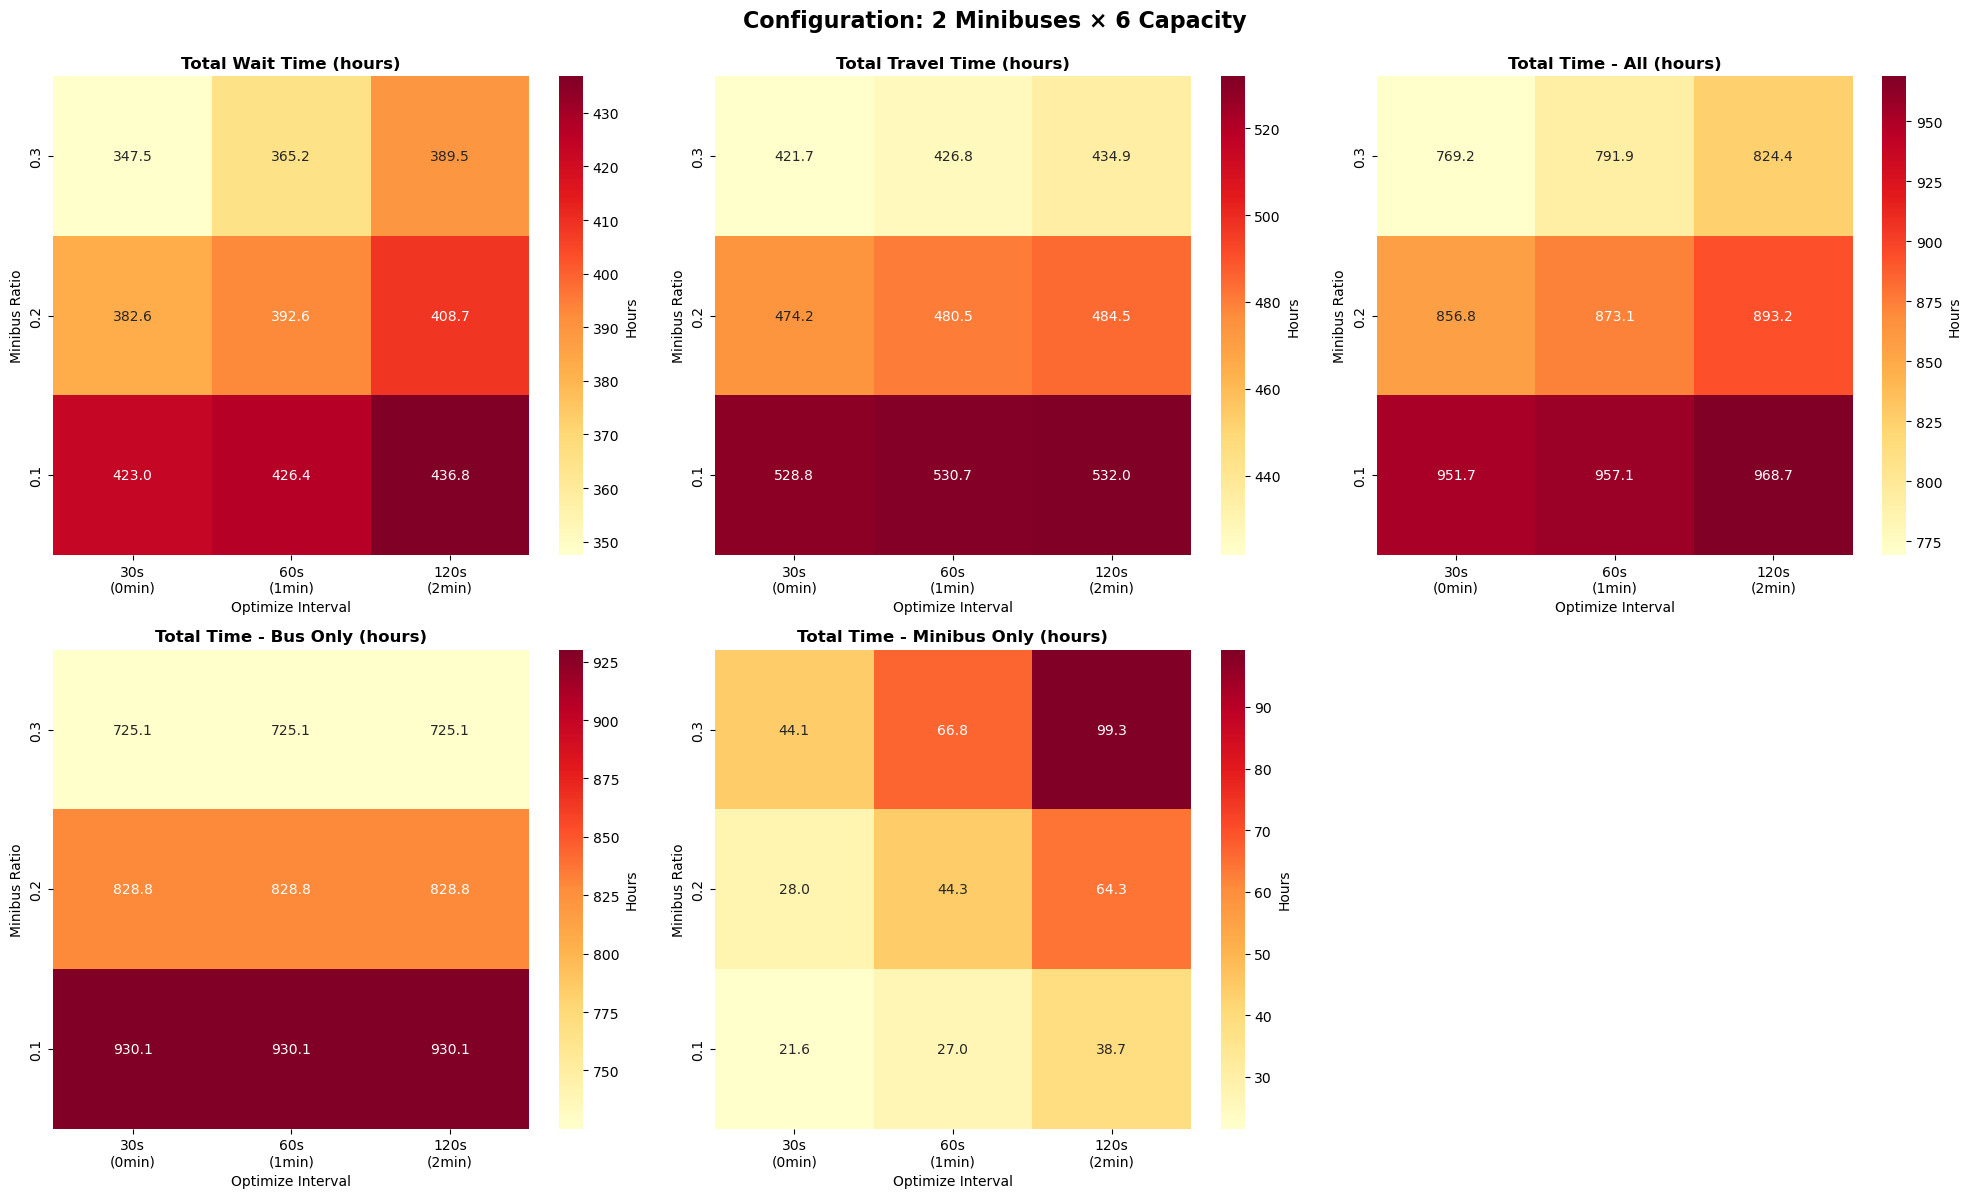

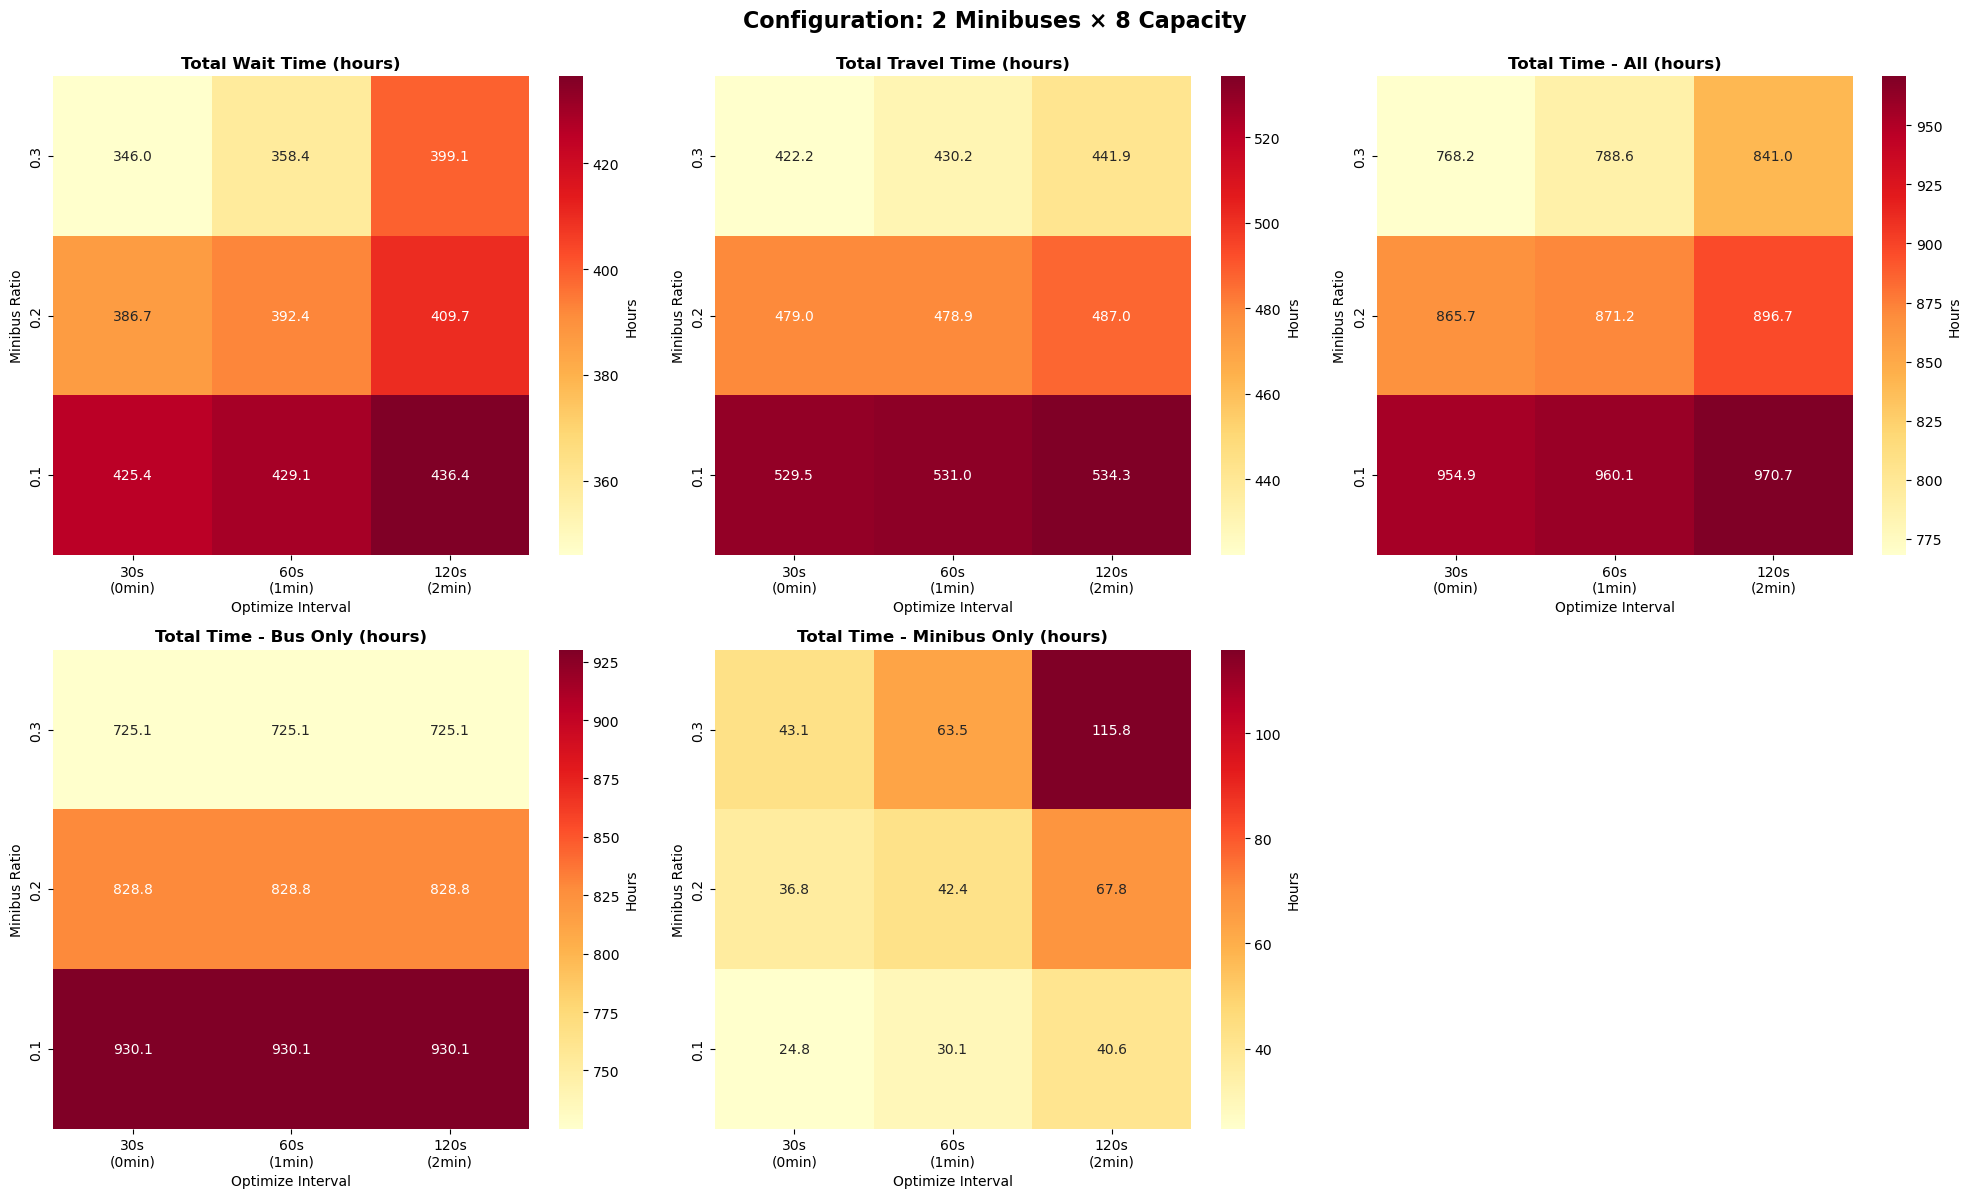

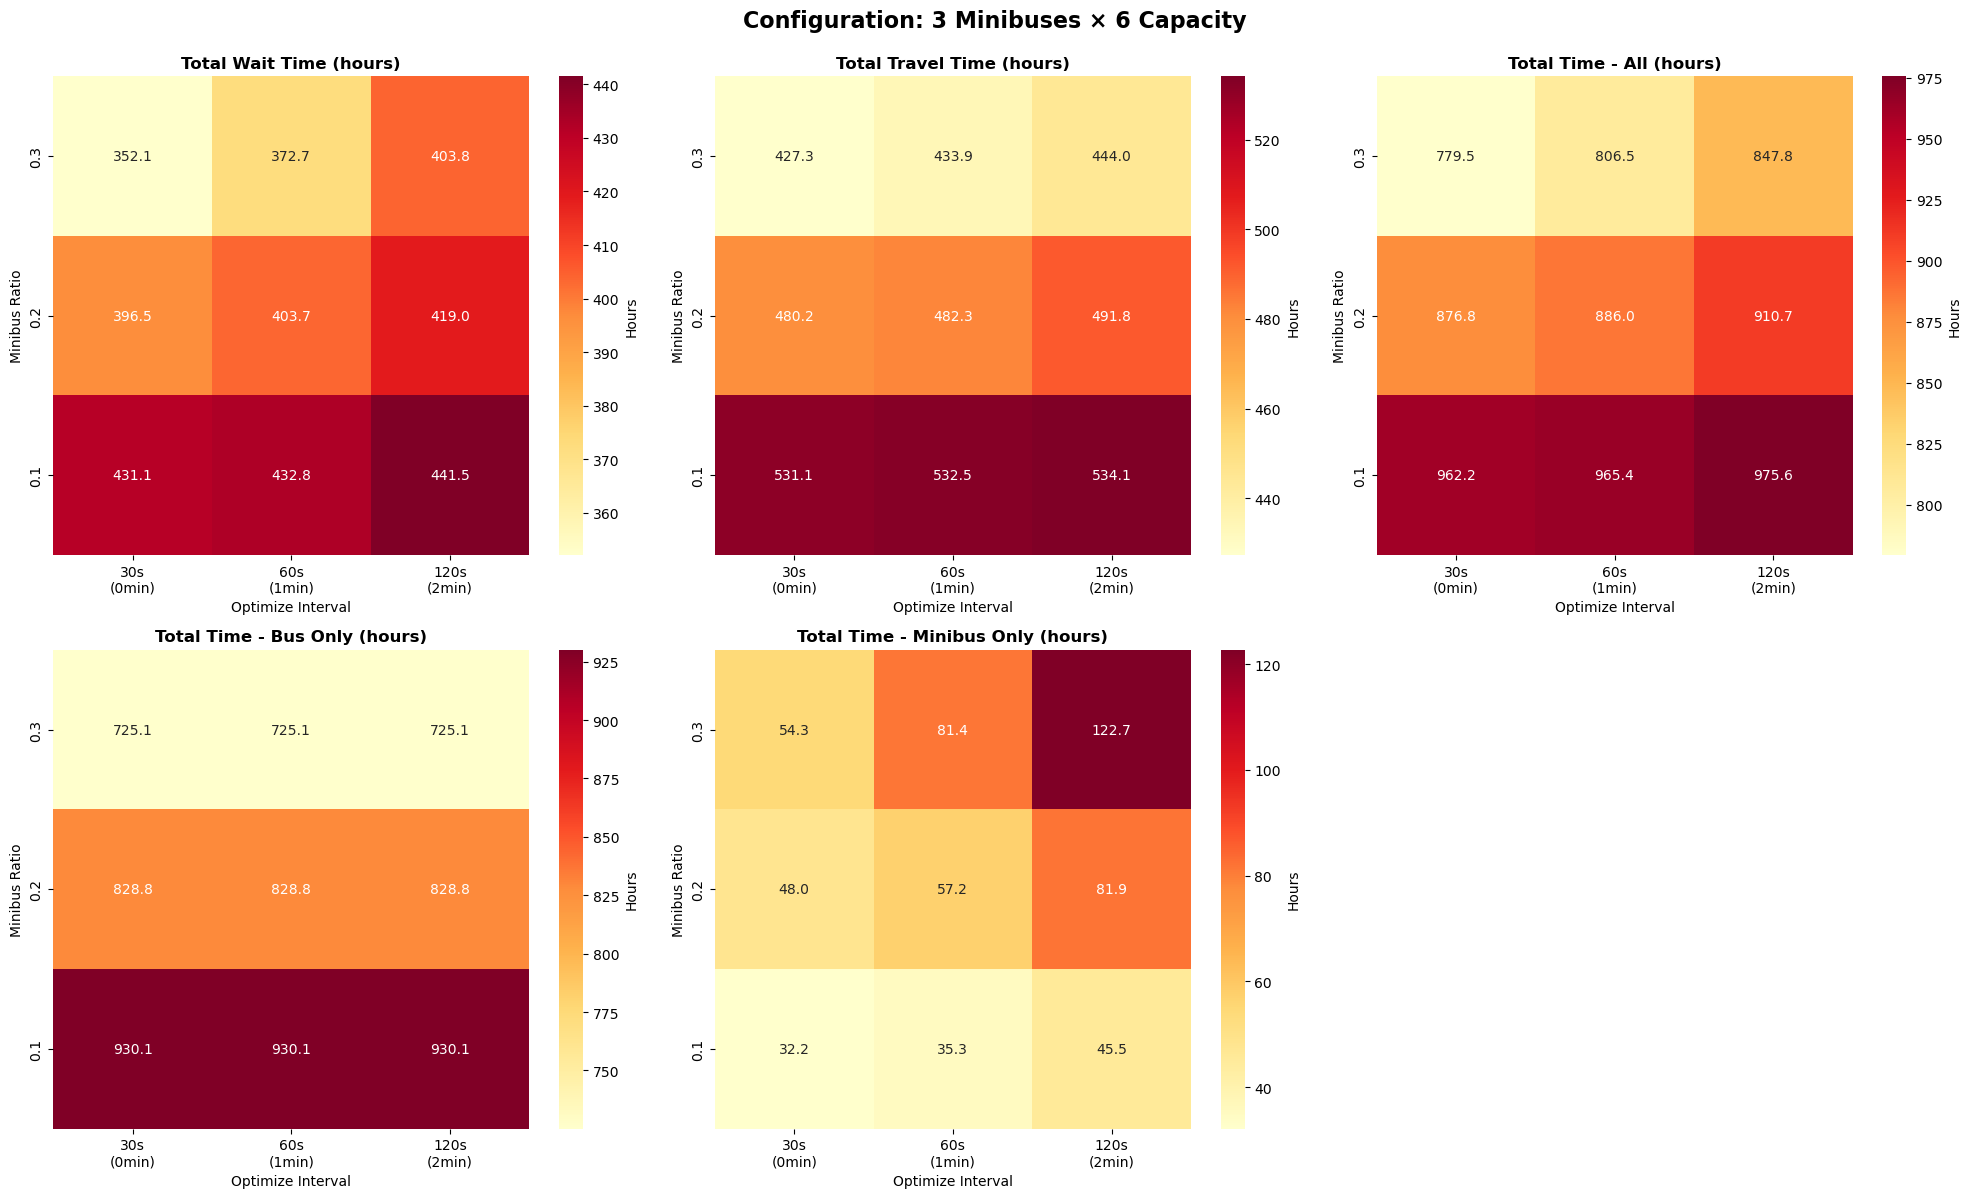

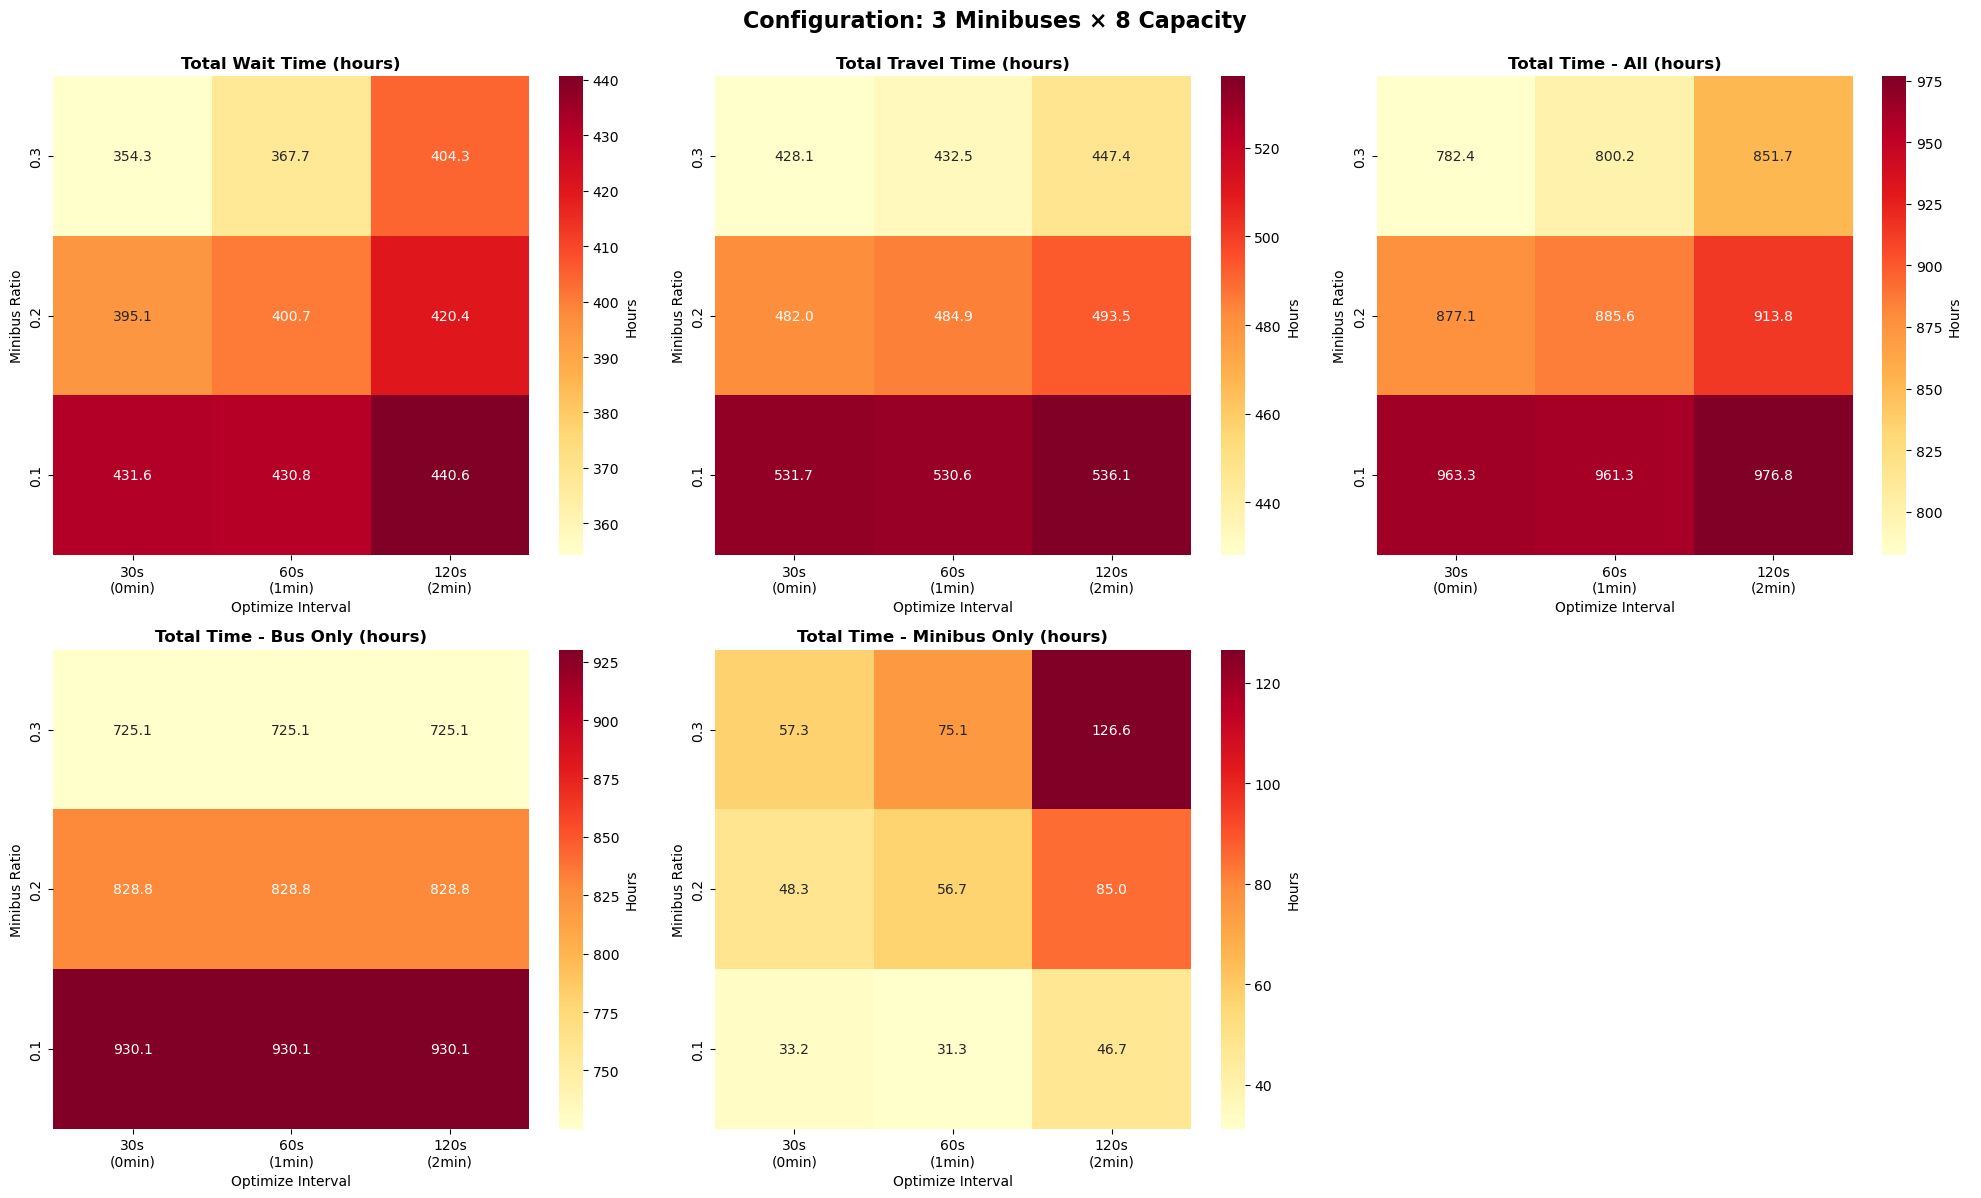

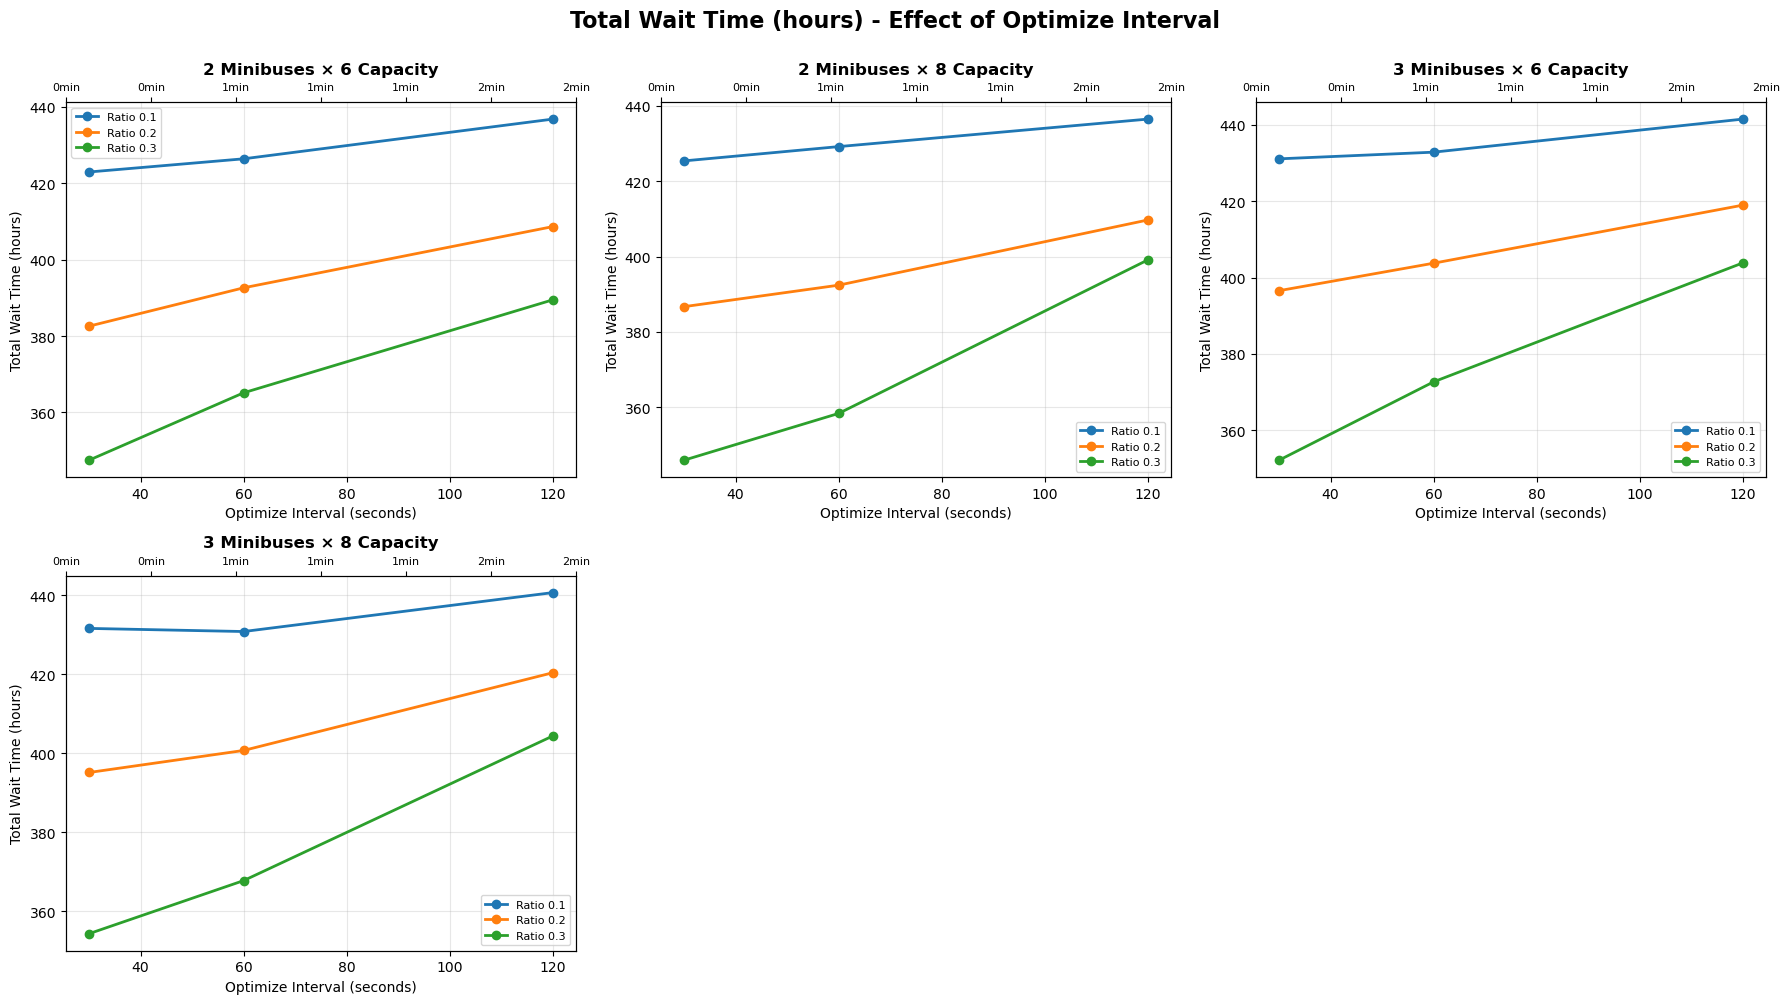

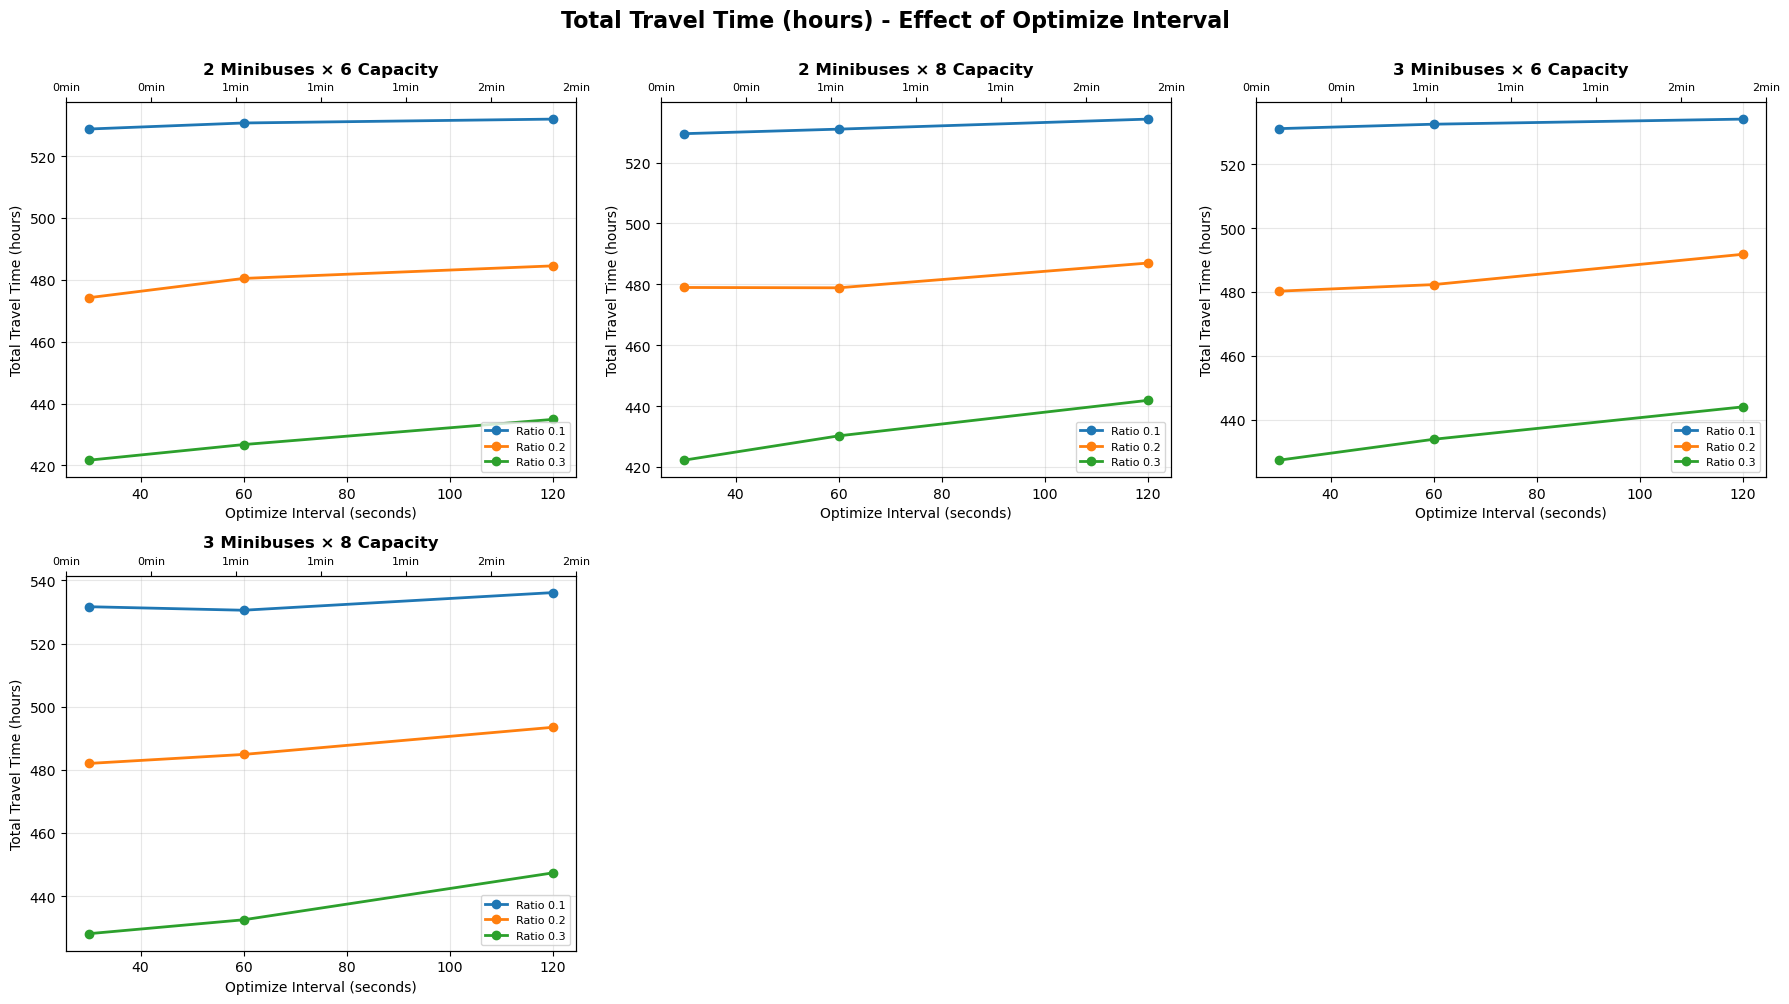

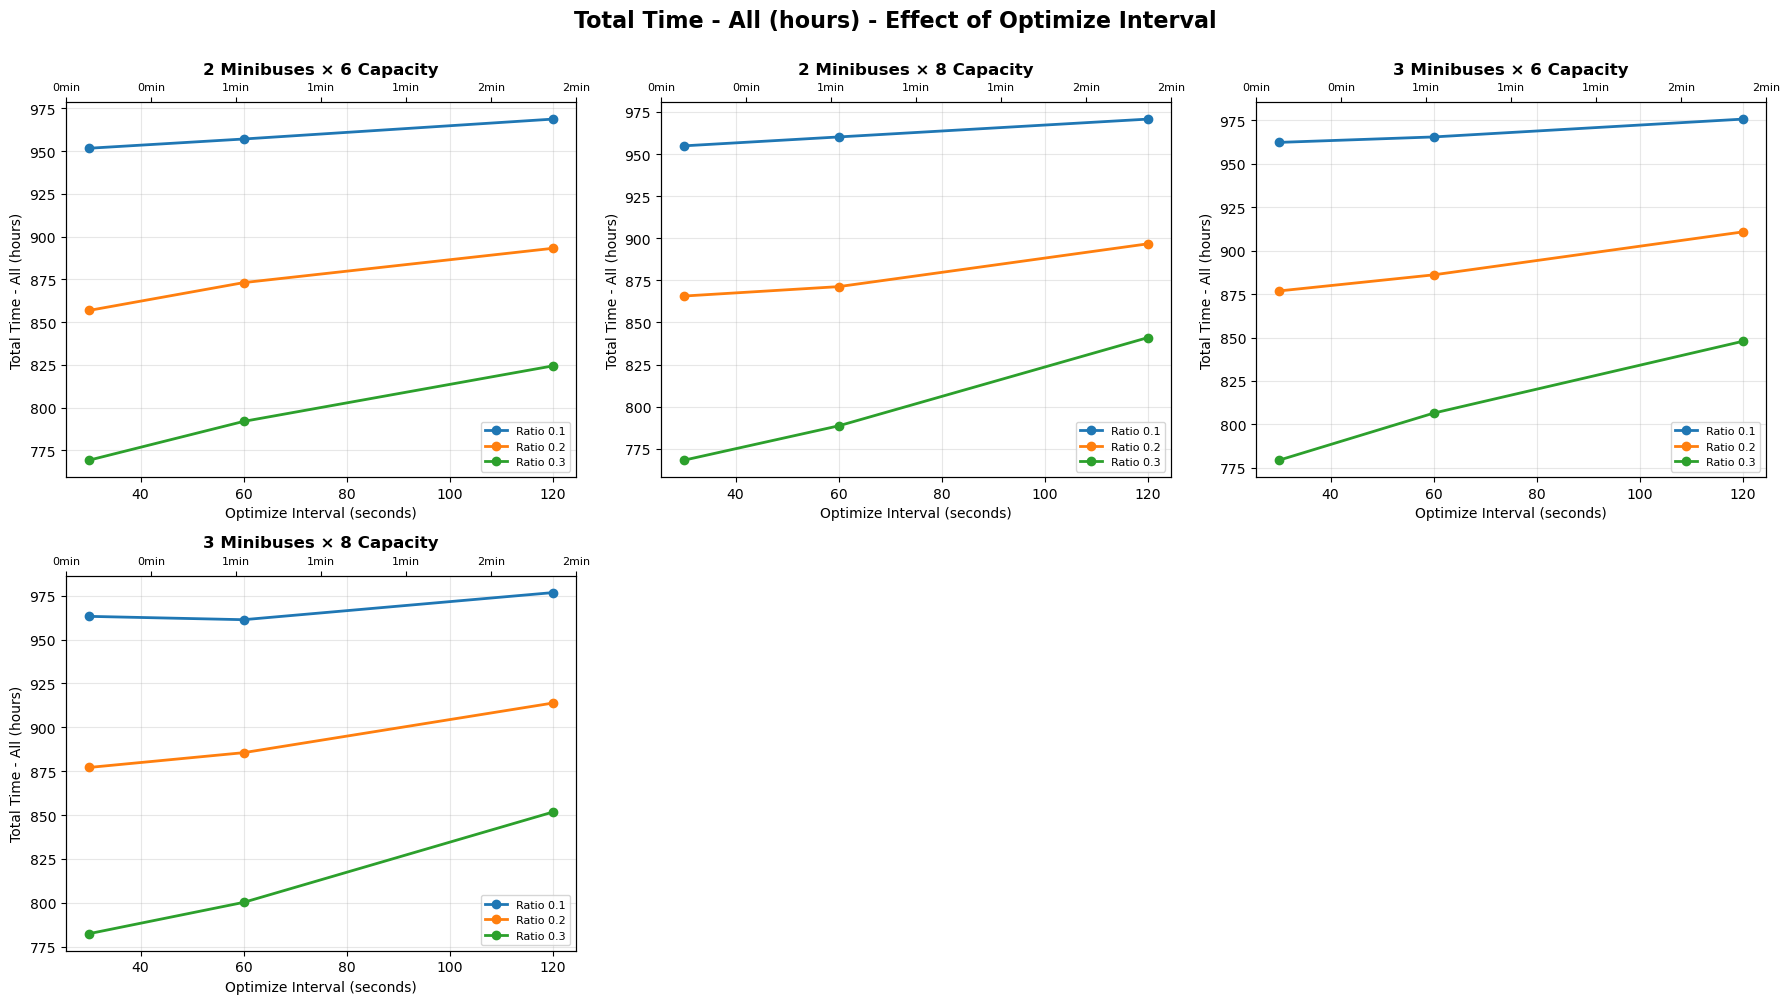

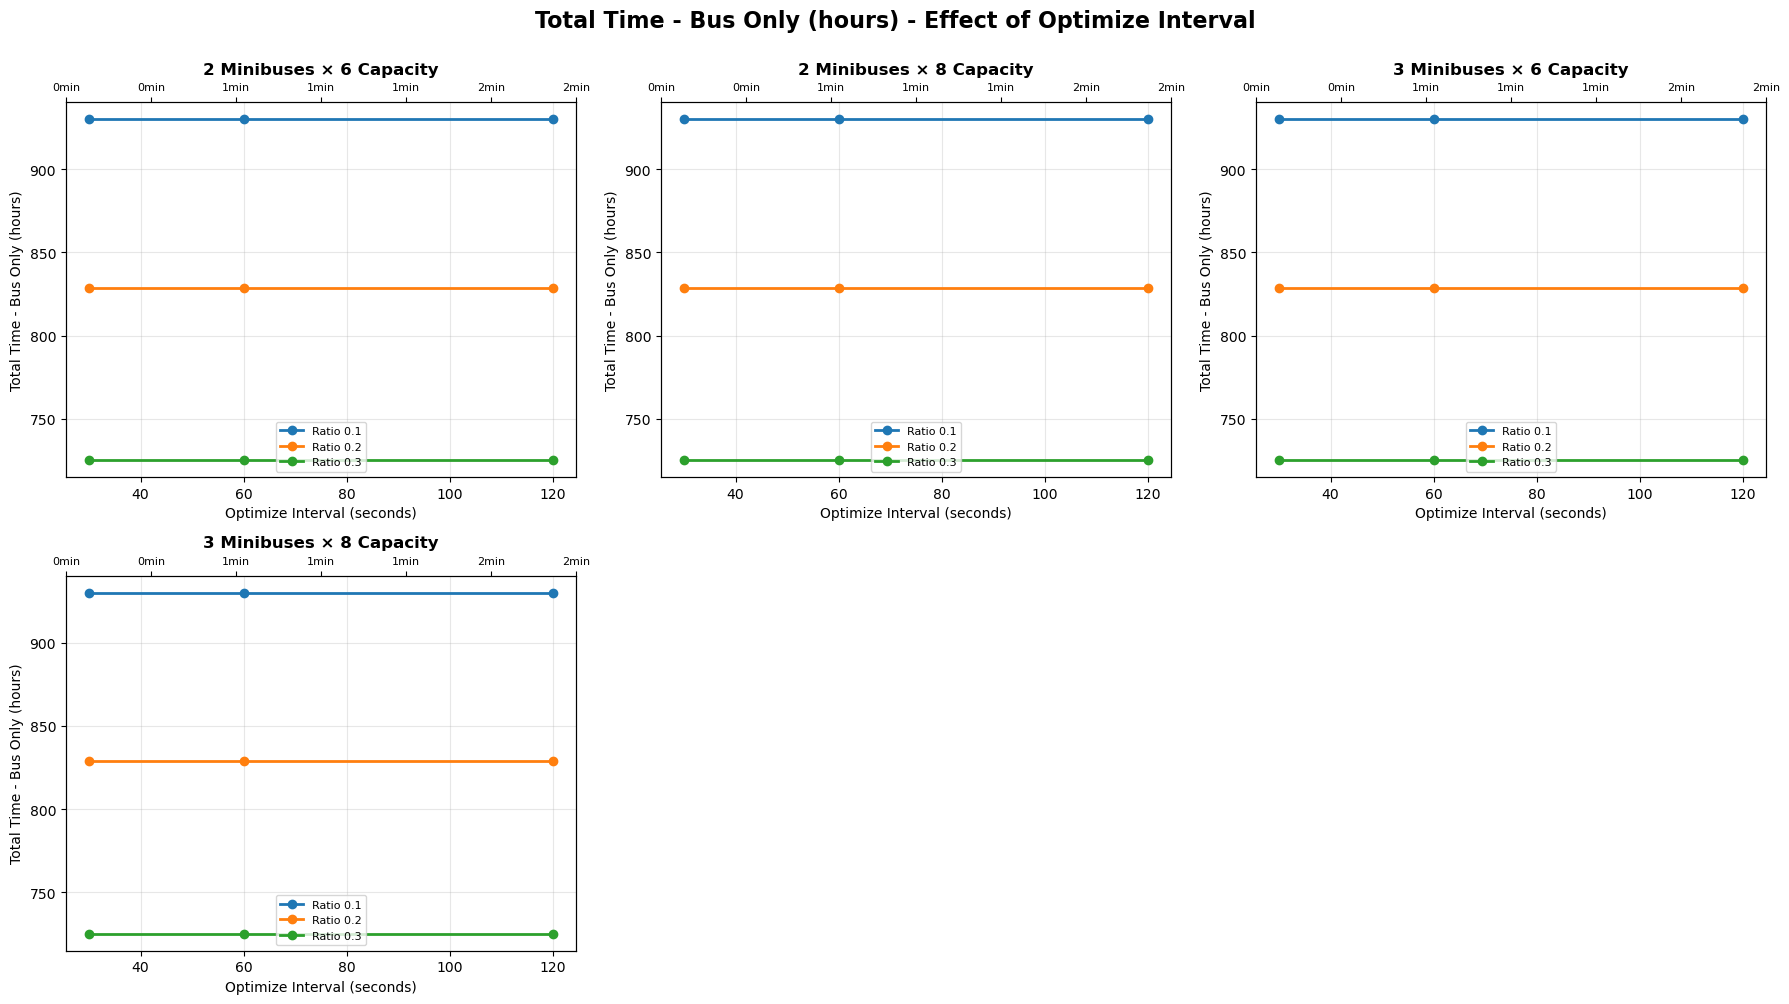

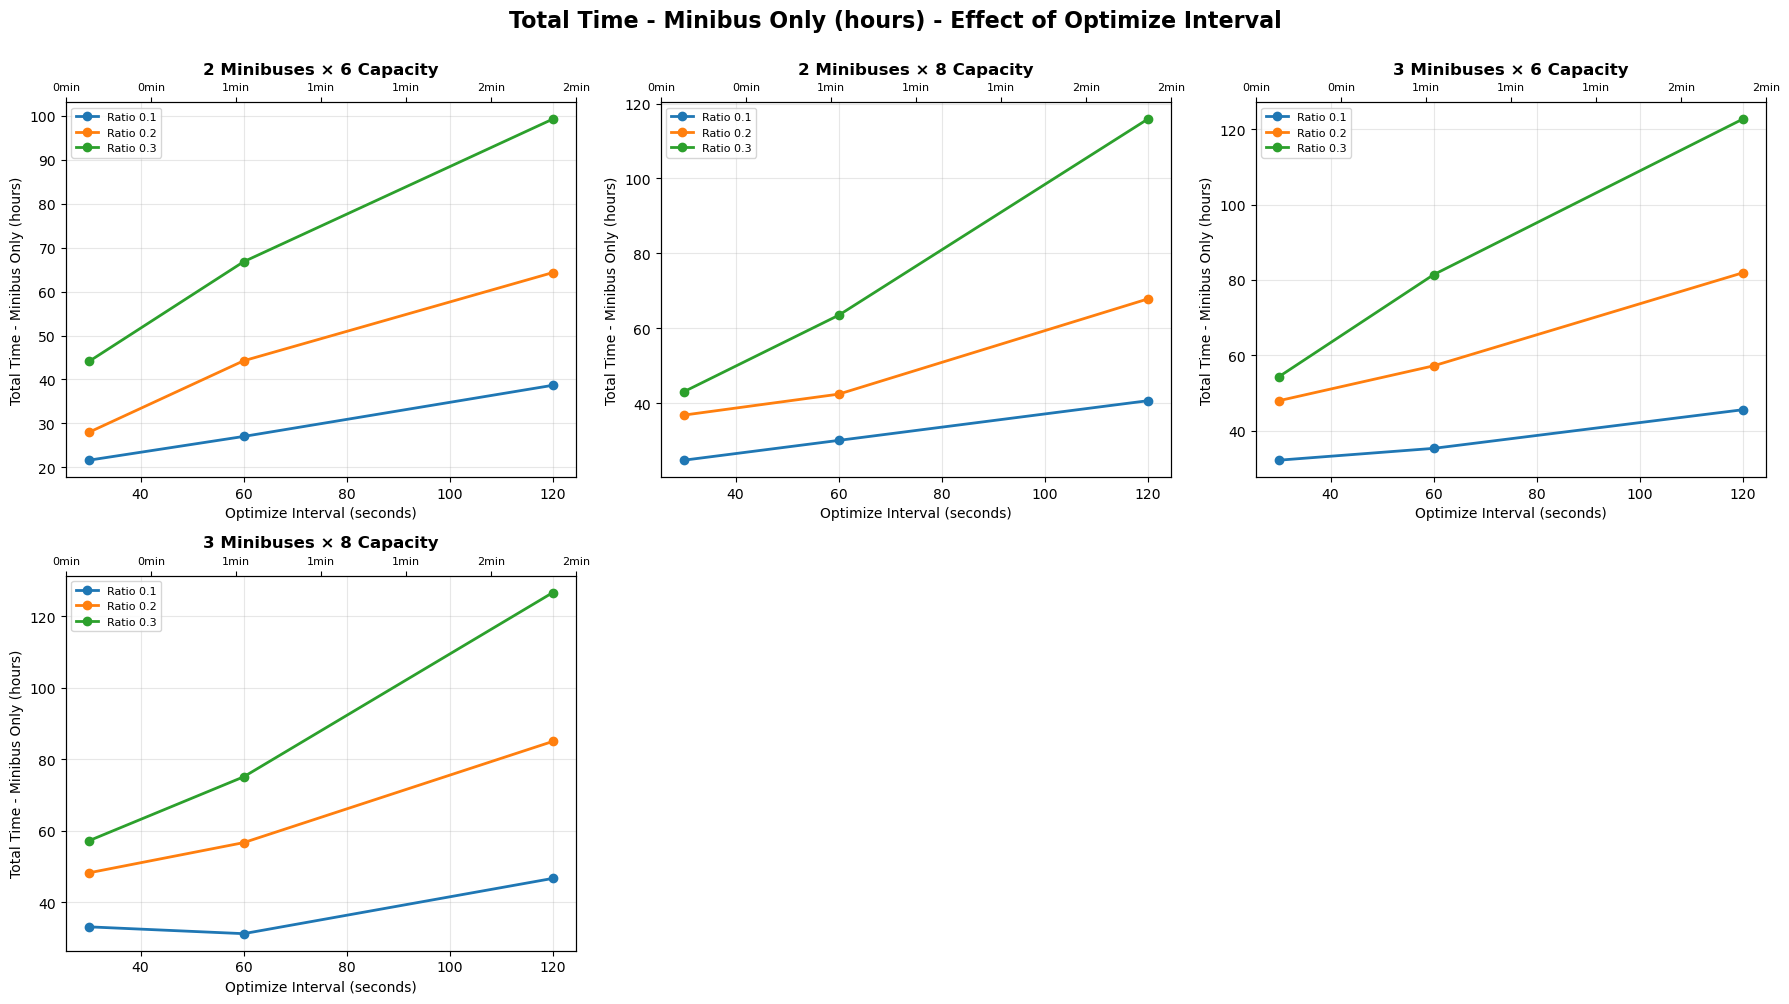

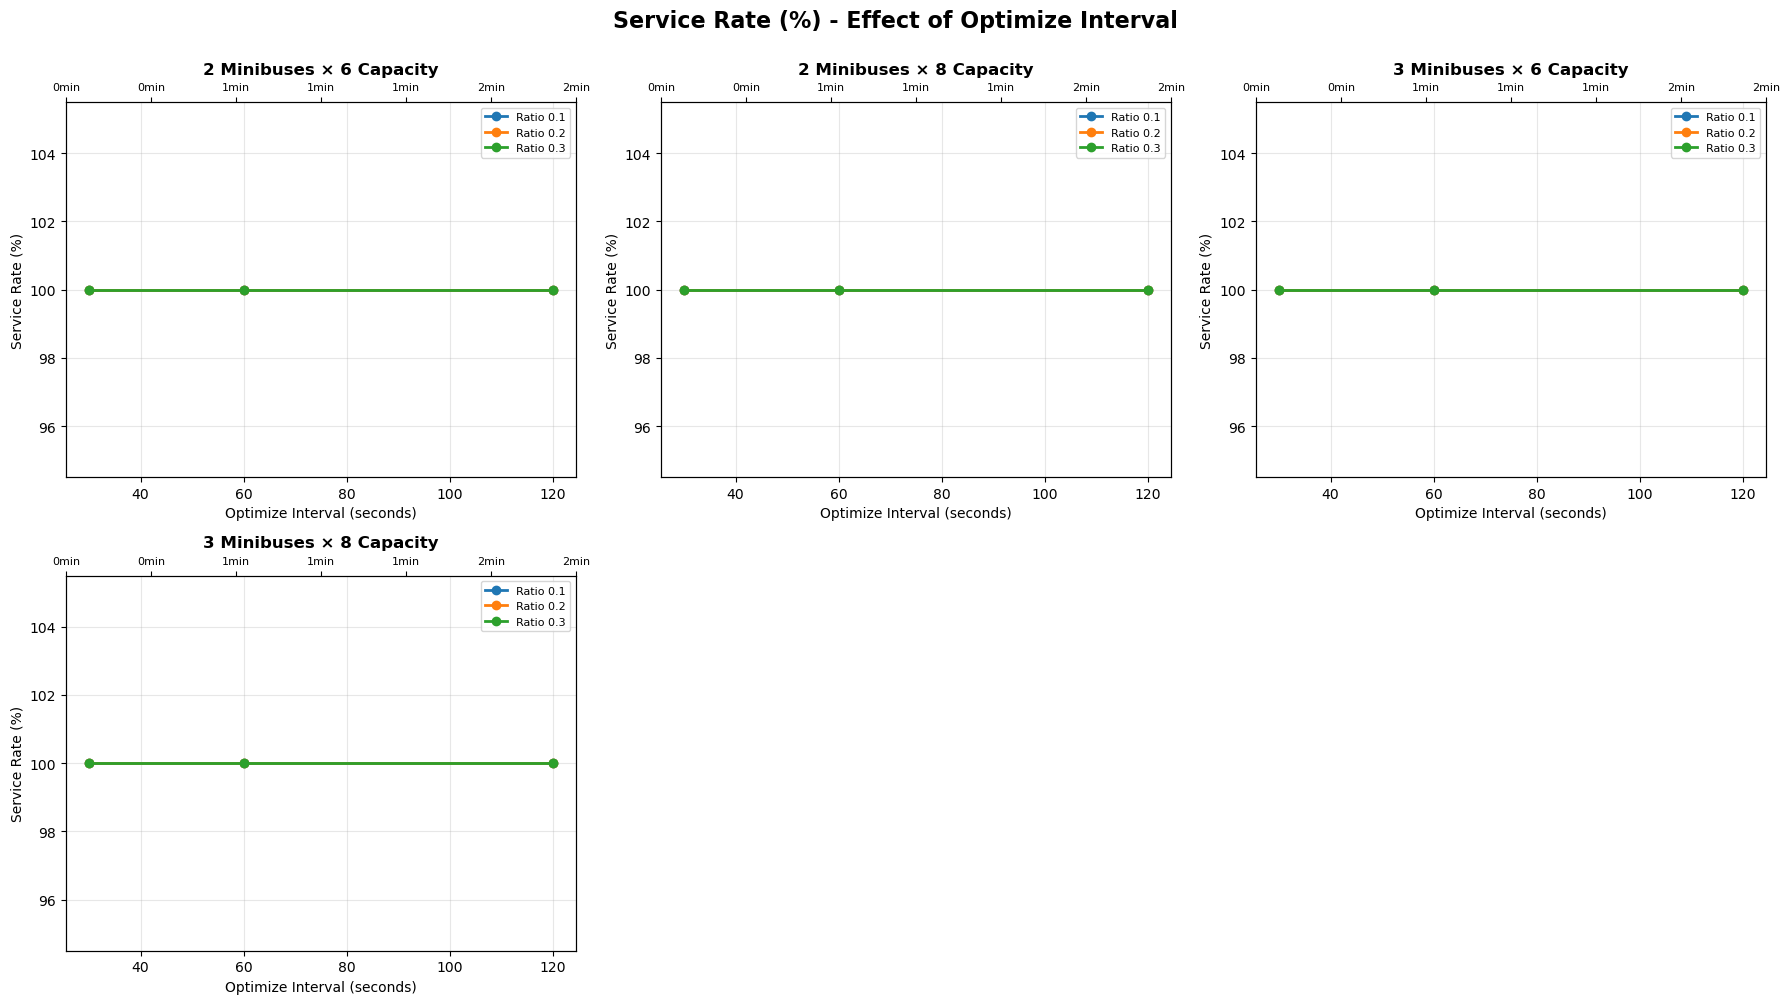

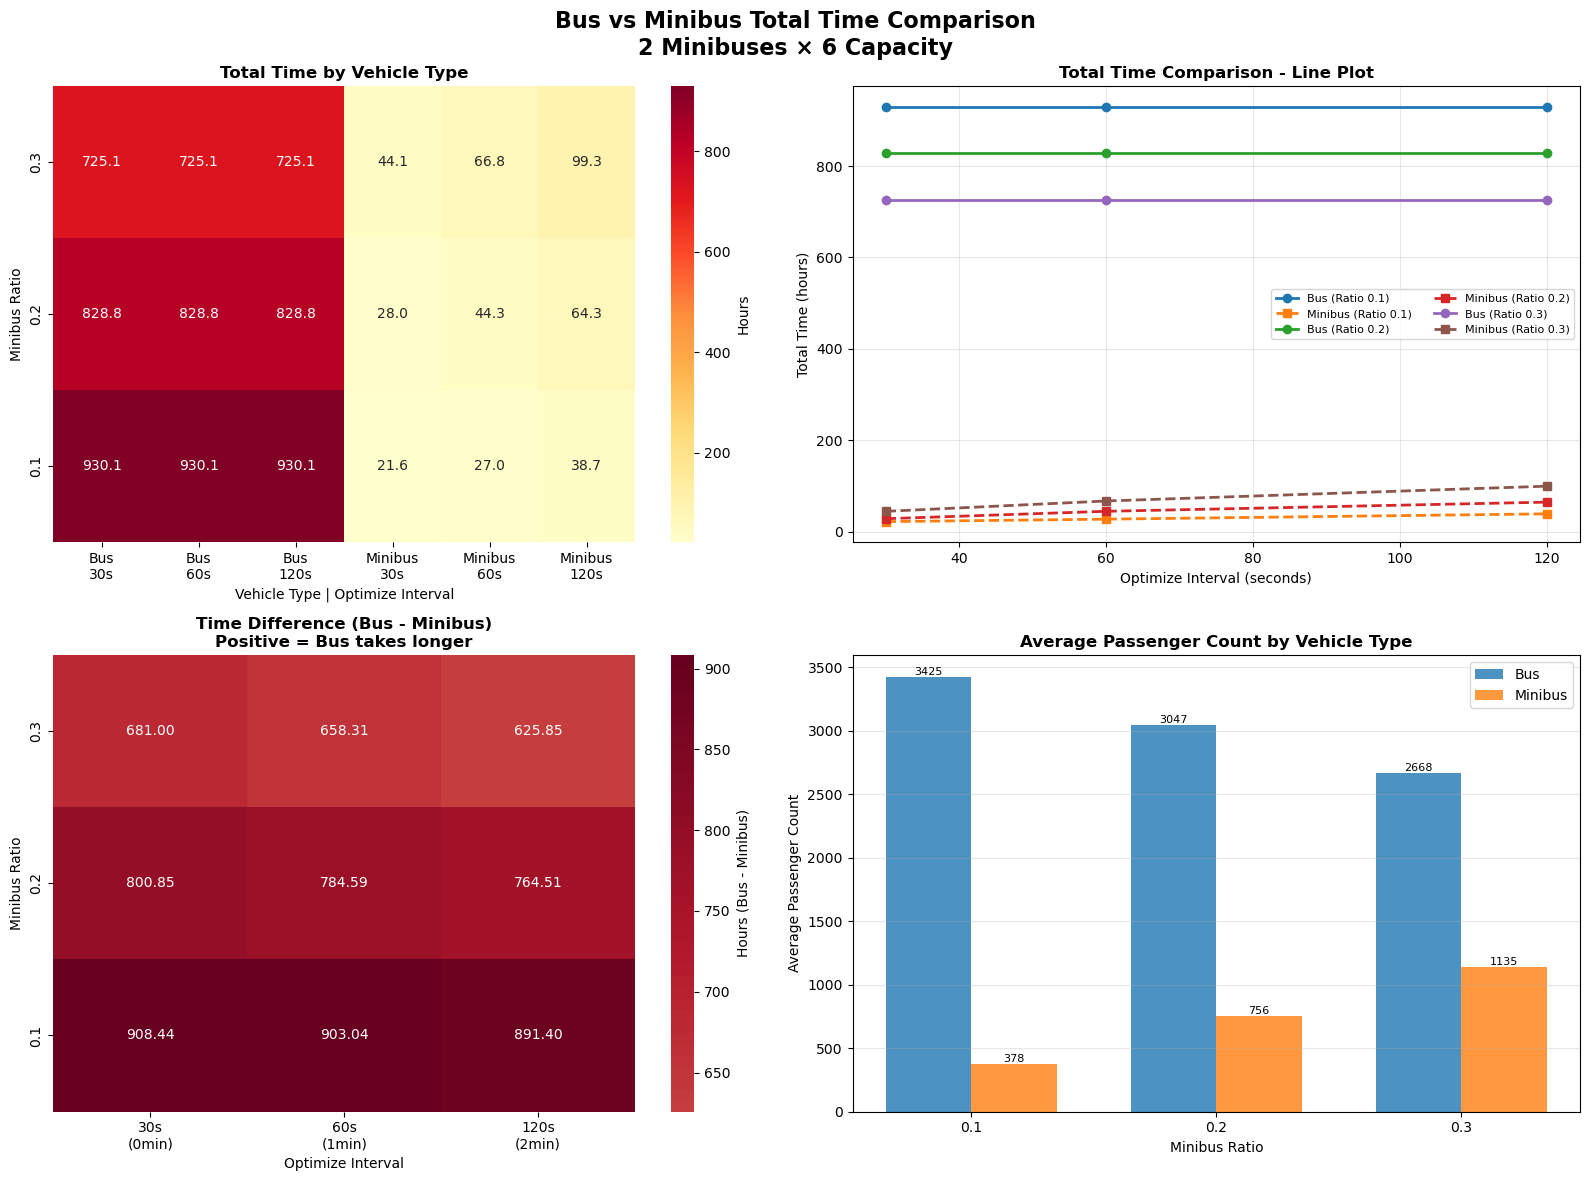

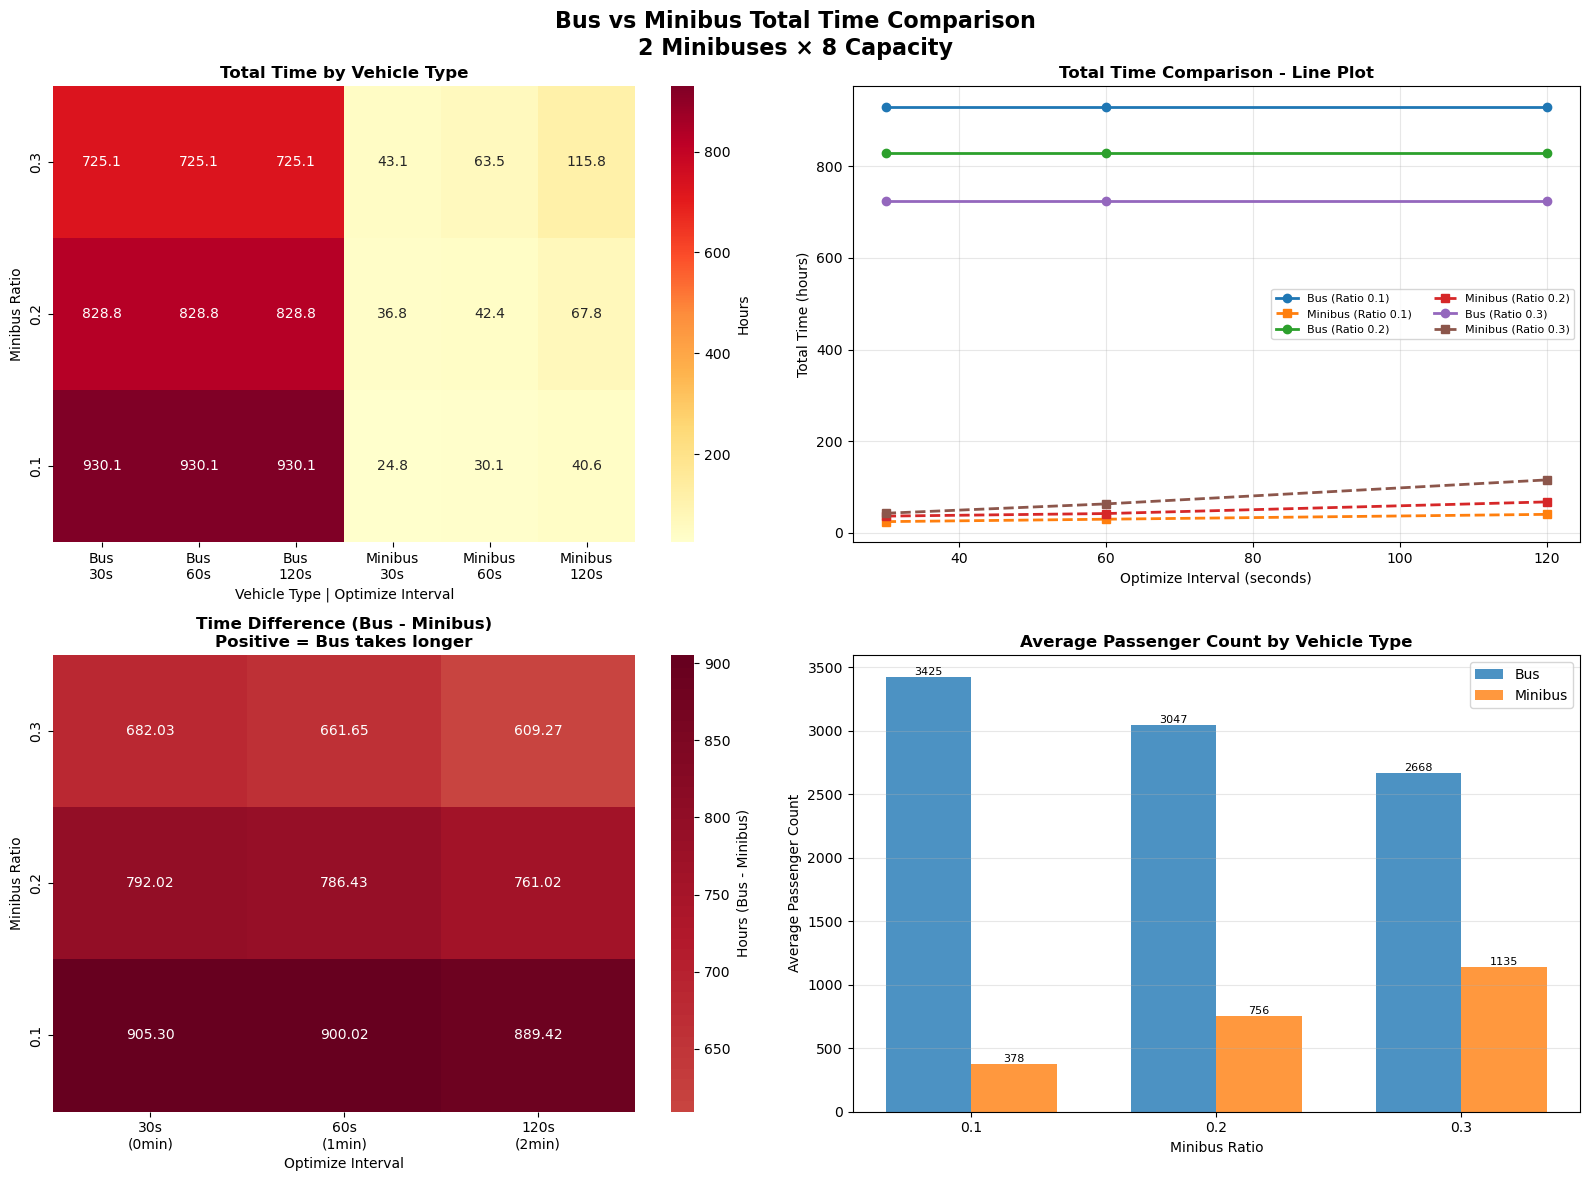

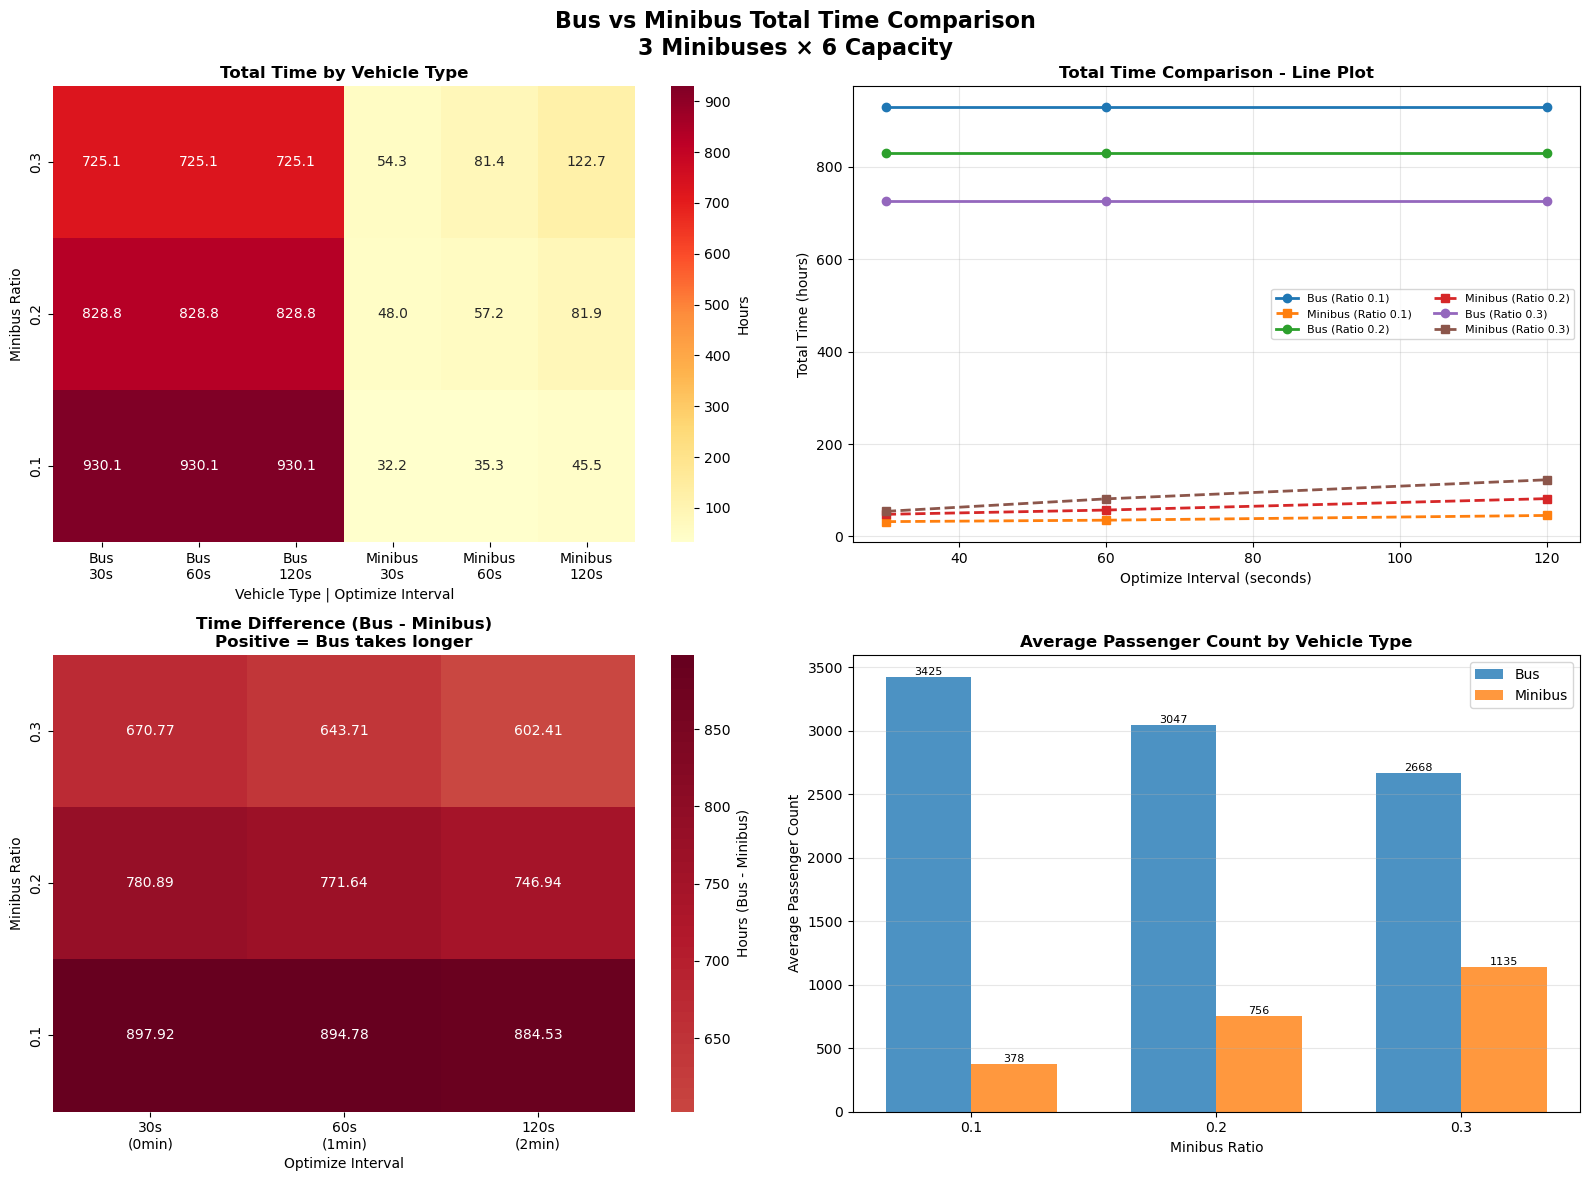

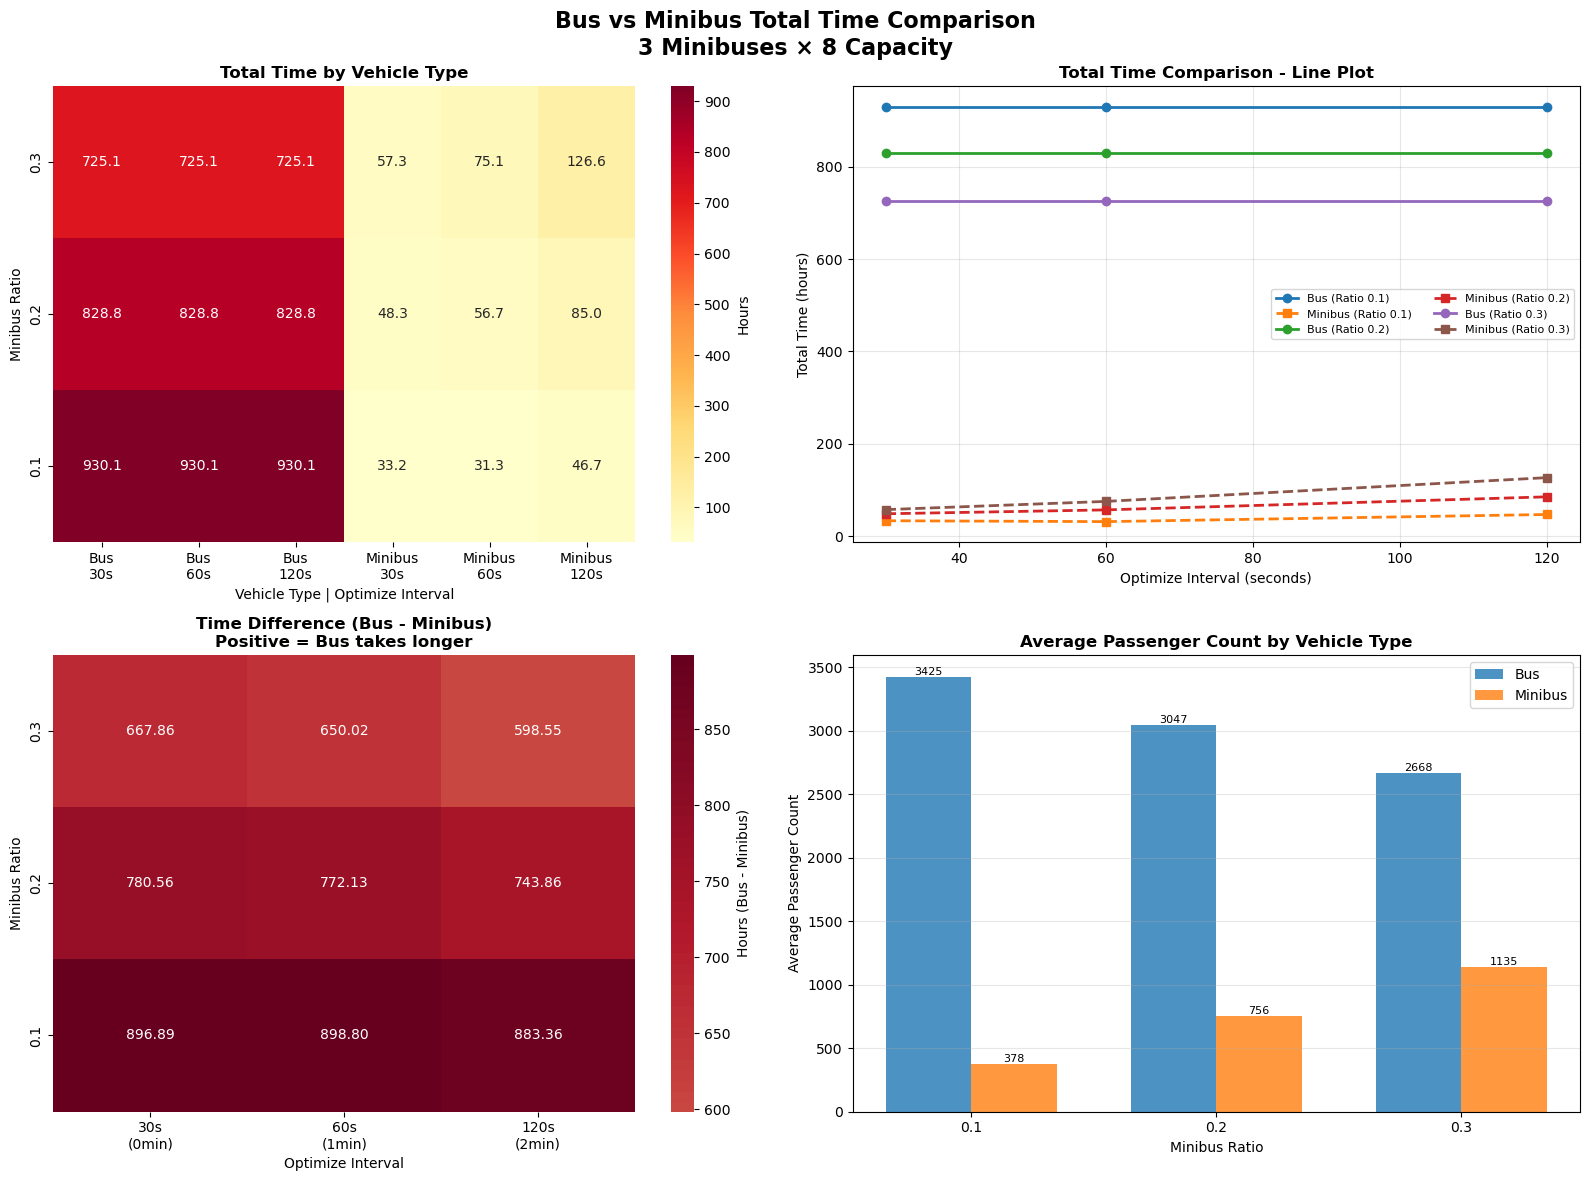

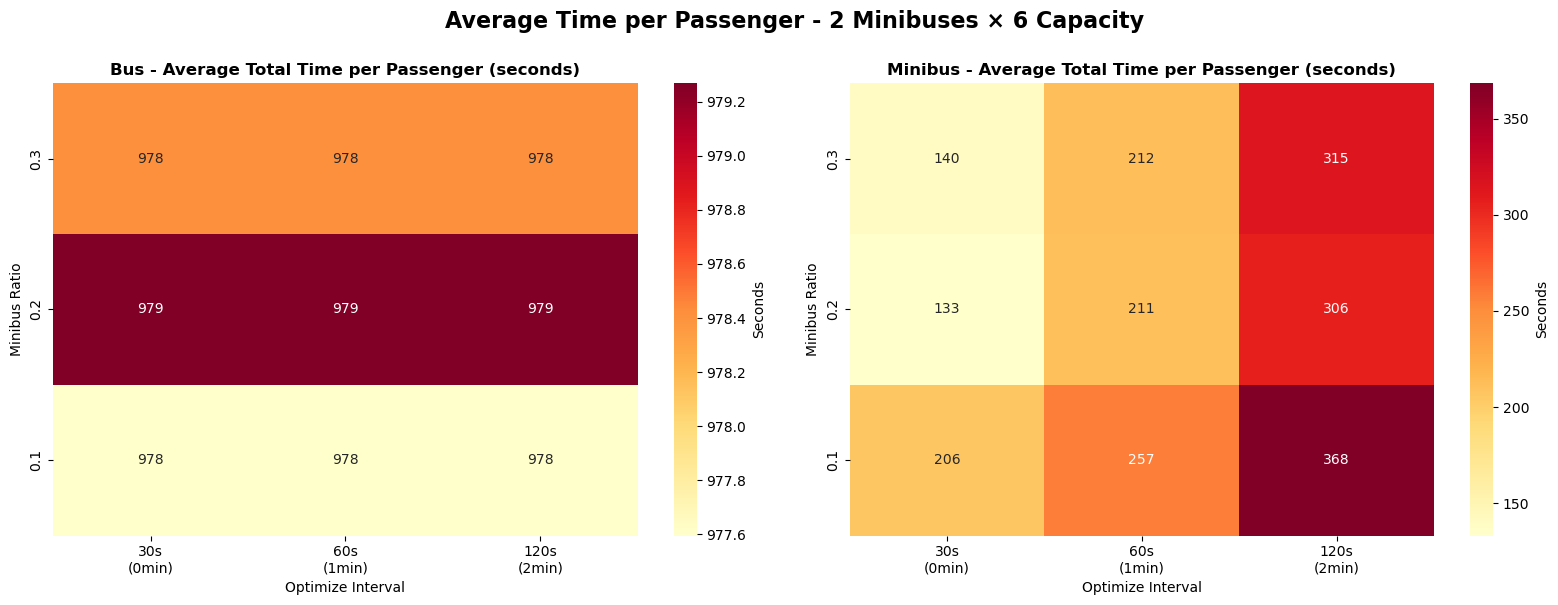

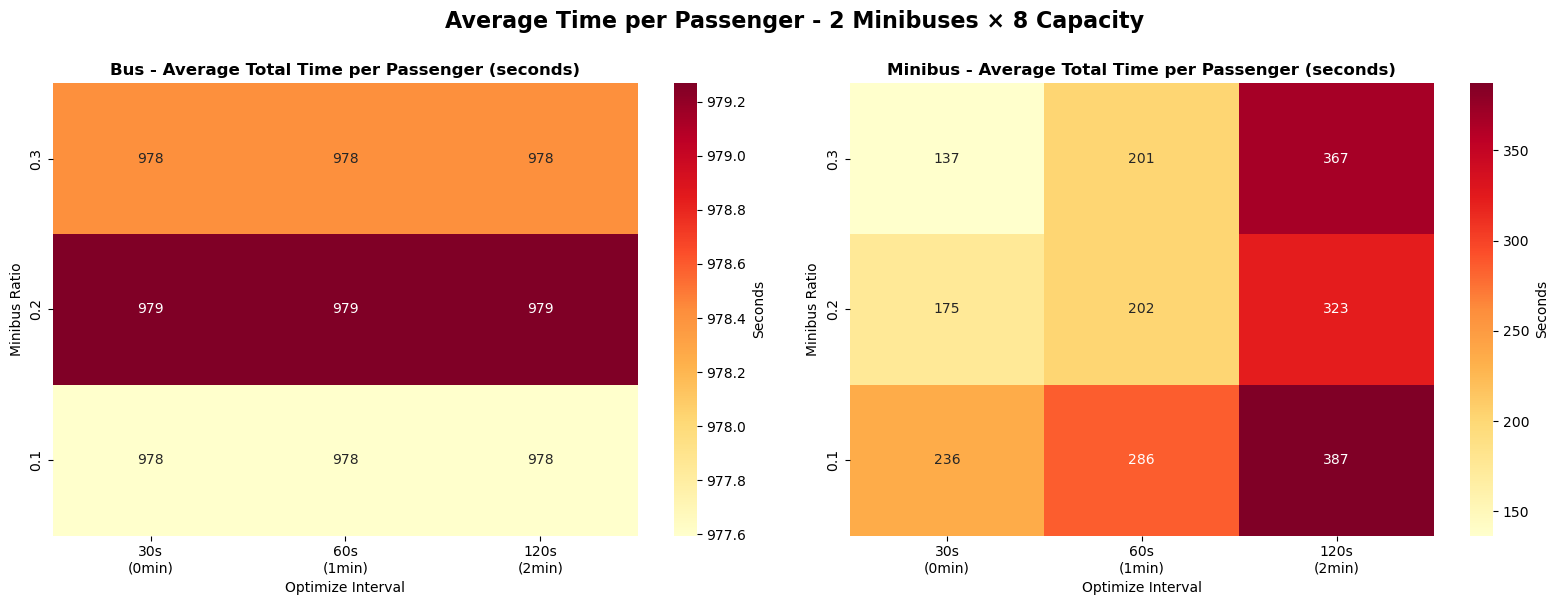

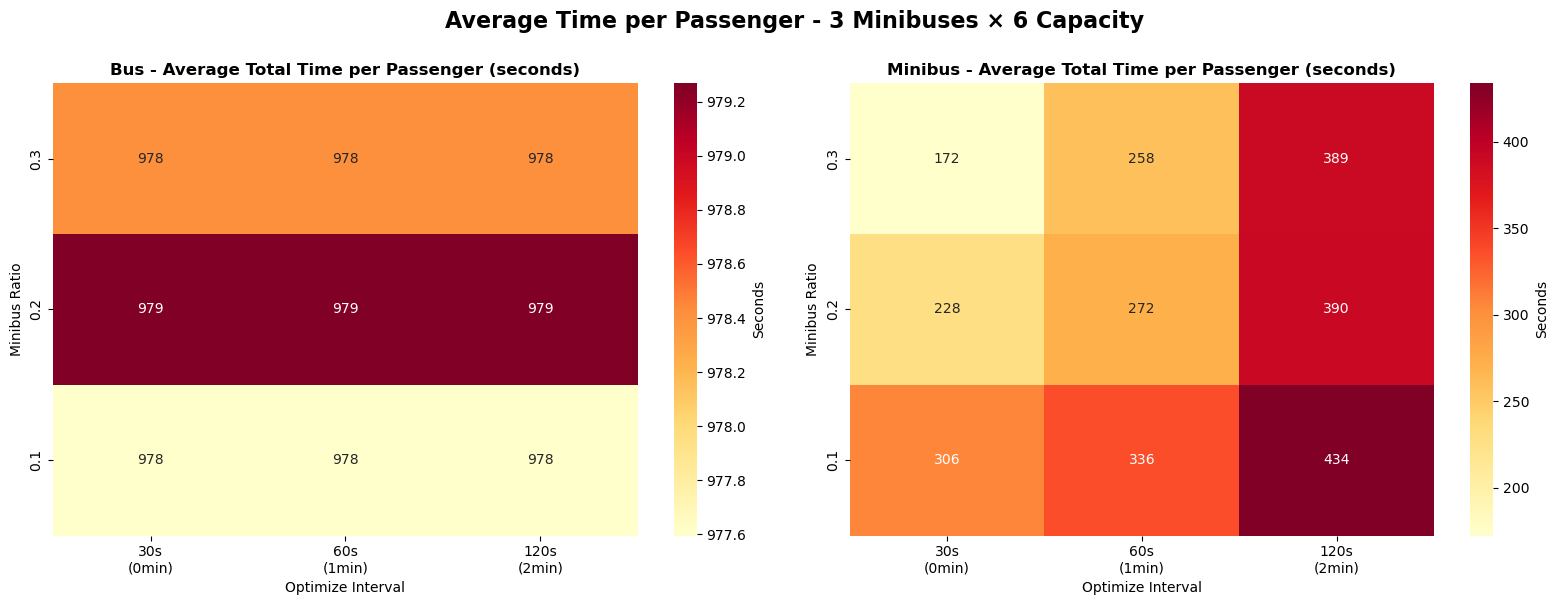

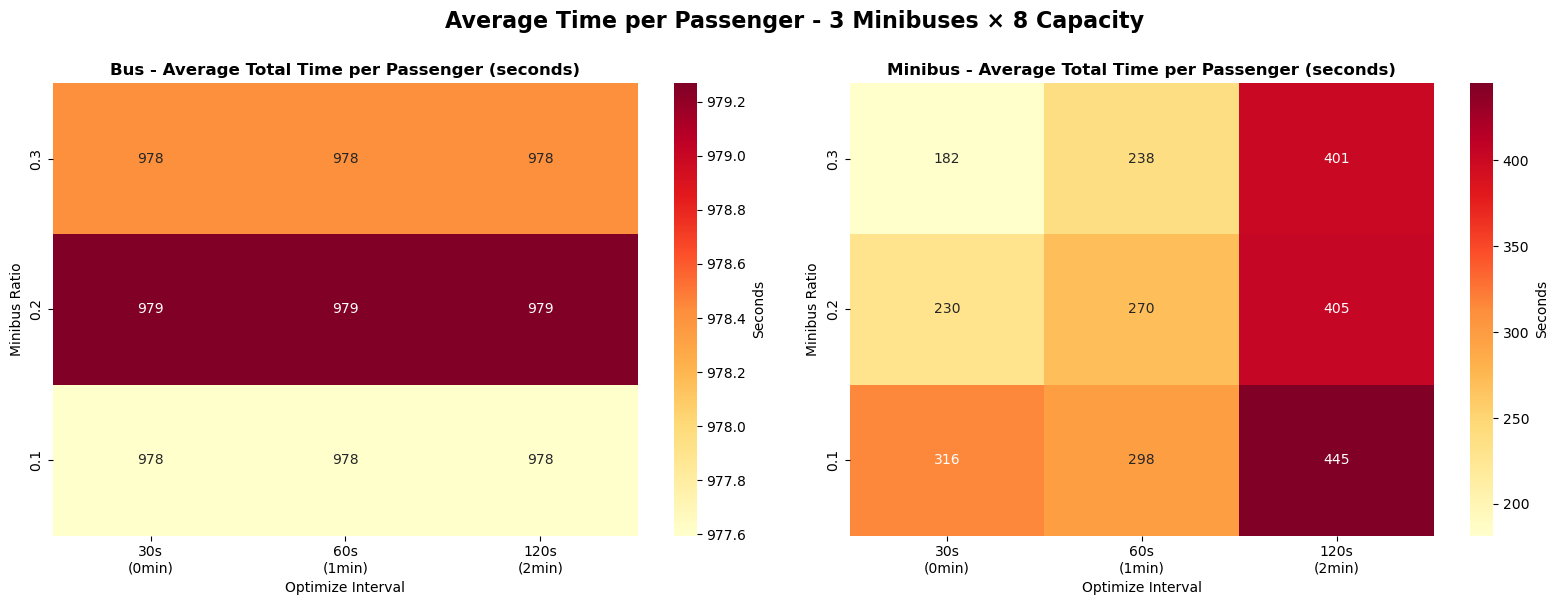

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read CSV file
df = pd.read_csv('Minibus_ratio_results/experiment_summary.csv')

# Check if optimization_interval column exists
if 'optimization_interval' not in df.columns:
    print("Warning: 'optimization_interval' column not found. Using original visualization.")
    has_optimize_interval = False
else:
    has_optimize_interval = True
    print(f"Found optimization_interval values: {sorted(df['optimization_interval'].unique())}")

# Check if vehicle-specific columns exist
has_vehicle_specific = all(col in df.columns for col in [
    'bus_avg_total_time', 'bus_total_total_time_hours', 
    'minibus_avg_total_time', 'minibus_total_total_time_hours'
])

if has_vehicle_specific:
    print("Found vehicle-specific total time columns!")
else:
    print("Warning: Vehicle-specific columns not found in CSV")

# Create a label column for display
df['capacity_label'] = df['num_minibuses'].astype(str) + '×' + df['minibus_capacity'].astype(str)

# Create a sorting key to control the order (2×6, 2×8, 2×10, 3×6, 3×8, 3×10)
df['sort_key'] = df['num_minibuses'] * 100 + df['minibus_capacity']

print("\nUnique capacity labels:")
print(df[['num_minibuses', 'minibus_capacity', 'capacity_label', 'sort_key']].drop_duplicates().sort_values('sort_key'))

# ============================================================================
# OPTION 1: Separate plots for each optimization_interval (ENHANCED)
# ============================================================================
if has_optimize_interval:
    optimize_intervals = sorted(df['optimization_interval'].unique())
    
    for opt_interval in optimize_intervals:
        # Filter data for this optimization_interval
        df_filtered = df[df['optimization_interval'] == opt_interval]
        
        # Create FIVE heatmaps (original 3 + Bus + Minibus)
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f'Optimize Interval = {opt_interval}s ({opt_interval//60} min)', 
                     fontsize=16, fontweight='bold', y=0.995)
        
        axes = axes.flatten()
        
        # Prepare data - create pivot tables for each metric
        metrics = [
            ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
            ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
            ('total_total_time_hours', 'Total Time - All (hours)', axes[2]),
            ('bus_total_total_time_hours', 'Total Time - Bus Only (hours)', axes[3]),
            ('minibus_total_total_time_hours', 'Total Time - Minibus Only (hours)', axes[4])
        ]
        
        for metric_col, title, ax in metrics:
            # Skip if column doesn't exist
            if metric_col not in df_filtered.columns:
                ax.text(0.5, 0.5, f'{title}\n(Data not available)', 
                       ha='center', va='center', fontsize=12)
                ax.axis('off')
                continue
            
            # Create pivot table with capacity_label as columns
            pivot_data = df_filtered.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='sort_key',
                aggfunc='mean'
            )
            
            # Create mapping from sort_key to display label
            label_mapping = df_filtered[['sort_key', 'capacity_label']].drop_duplicates().set_index('sort_key')['capacity_label'].to_dict()
            
            # Rename columns to display labels
            pivot_data.columns = [label_mapping[col] for col in pivot_data.columns]
            
            # Plot heatmap
            sns.heatmap(
                pivot_data,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Hours'}
            )
            
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Number × Capacity', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            
            # Invert y-axis so ratio goes from small to large
            ax.invert_yaxis()
        
        # Hide the last subplot (we have 5 metrics in 6 positions)
        axes[5].axis('off')
        
        plt.tight_layout()
        # plt.savefig(f'heatmap_opt_{opt_interval}s.png', dpi=300, bbox_inches='tight')
        # print(f"\nSaved: heatmap_opt_{opt_interval}s.png")

# ============================================================================
# OPTION 2: Combined comparison plots showing effect of optimization_interval (ENHANCED)
# ============================================================================
if has_optimize_interval:
    print("\n" + "="*70)
    print("Creating comparison plots across optimize intervals...")
    print("="*70)
    
    # For each capacity configuration, show how metrics vary with optimization_interval and ratio
    capacity_configs = df.groupby(['num_minibuses', 'minibus_capacity']).size().index.tolist()
    
    for num_minibuses, capacity in capacity_configs:
        df_config = df[(df['num_minibuses'] == num_minibuses) & 
                       (df['minibus_capacity'] == capacity)]
        
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f'Configuration: {num_minibuses} Minibuses × {capacity} Capacity', 
                     fontsize=16, fontweight='bold', y=0.995)
        
        axes = axes.flatten()
        
        metrics = [
            ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
            ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
            ('total_total_time_hours', 'Total Time - All (hours)', axes[2]),
            ('bus_total_total_time_hours', 'Total Time - Bus Only (hours)', axes[3]),
            ('minibus_total_total_time_hours', 'Total Time - Minibus Only (hours)', axes[4])
        ]
        
        for metric_col, title, ax in metrics:
            # Skip if column doesn't exist
            if metric_col not in df_config.columns:
                ax.text(0.5, 0.5, f'{title}\n(Data not available)', 
                       ha='center', va='center', fontsize=12)
                ax.axis('off')
                continue
            
            # Create pivot table: ratio vs optimization_interval
            pivot_data = df_config.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='optimization_interval',
                aggfunc='mean'
            )
            
            # Rename columns to show minutes
            pivot_data.columns = [f'{int(col)}s\n({int(col//60)}min)' for col in pivot_data.columns]
            
            # Plot heatmap
            sns.heatmap(
                pivot_data,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Hours'}
            )
            
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            
            # Invert y-axis so ratio goes from small to large
            ax.invert_yaxis()
        
        # Hide the last subplot
        axes[5].axis('off')
        
        plt.tight_layout()
        filename = f'comparison_n{num_minibuses}_c{capacity}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# OPTION 3: Line plots showing trends (ENHANCED)
# ============================================================================
if has_optimize_interval:
    print("\n" + "="*70)
    print("Creating line plots showing trends...")
    print("="*70)
    
    # Create line plots for each metric (EXPANDED)
    metrics_to_plot = [
        ('total_wait_time_hours', 'Total Wait Time (hours)'),
        ('total_travel_time_hours', 'Total Travel Time (hours)'),
        ('total_total_time_hours', 'Total Time - All (hours)'),
        ('bus_total_total_time_hours', 'Total Time - Bus Only (hours)'),
        ('minibus_total_total_time_hours', 'Total Time - Minibus Only (hours)'),
        ('service_rate', 'Service Rate (%)')
    ]
    
    for metric_col, metric_name in metrics_to_plot:
        # Skip if column doesn't exist
        if metric_col not in df.columns:
            print(f"Skipping {metric_name} - column not found")
            continue
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'{metric_name} - Effect of Optimize Interval', 
                     fontsize=16, fontweight='bold', y=1.00)
        axes = axes.flatten()
        
        # For each capacity configuration
        for idx, (num_minibuses, capacity) in enumerate(capacity_configs):
            if idx >= len(axes):
                break
                
            ax = axes[idx]
            df_config = df[(df['num_minibuses'] == num_minibuses) & 
                           (df['minibus_capacity'] == capacity)]
            
            # Plot lines for each minibus_ratio
            for ratio in sorted(df_config['minibus_ratio'].unique()):
                df_ratio = df_config[df_config['minibus_ratio'] == ratio]
                df_ratio_sorted = df_ratio.sort_values('optimization_interval')
                
                ax.plot(df_ratio_sorted['optimization_interval'], 
                       df_ratio_sorted[metric_col],
                       marker='o', 
                       label=f'Ratio {ratio}',
                       linewidth=2,
                       markersize=6)
            
            ax.set_title(f'{num_minibuses} Minibuses × {capacity} Capacity', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval (seconds)', fontsize=10)
            ax.set_ylabel(metric_name, fontsize=10)
            ax.legend(loc='best', fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Add secondary x-axis showing minutes
            ax2 = ax.twiny()
            ax2.set_xlim(ax.get_xlim())
            ax2.set_xticks(ax.get_xticks())
            ax2.set_xticklabels([f'{int(x//60)}min' for x in ax.get_xticks()], fontsize=8)
        
        # Hide unused subplots
        for idx in range(len(capacity_configs), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        filename = f'lineplot_{metric_col}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# NEW: Comparison plot - Bus vs Minibus total time
# ============================================================================
if has_optimize_interval and has_vehicle_specific:
    print("\n" + "="*70)
    print("Creating Bus vs Minibus comparison plots...")
    print("="*70)
    
    for num_minibuses, capacity in capacity_configs:
        df_config = df[(df['num_minibuses'] == num_minibuses) & 
                       (df['minibus_capacity'] == capacity)]
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'Bus vs Minibus Total Time Comparison\n{num_minibuses} Minibuses × {capacity} Capacity', 
                     fontsize=16, fontweight='bold', y=0.98)
        
        # 1. Side-by-side comparison heatmap
        ax = axes[0, 0]
        metrics_compare = [
            ('bus_total_total_time_hours', 'Bus'),
            ('minibus_total_total_time_hours', 'Minibus')
        ]
        
        comparison_data = []
        for metric_col, label in metrics_compare:
            pivot = df_config.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='optimization_interval',
                aggfunc='mean'
            )
            comparison_data.append(pivot)
        
        # Concatenate side by side
        combined = pd.concat(comparison_data, axis=1, keys=['Bus', 'Minibus'])
        
        # Flatten column names for display
        combined.columns = [f'{vtype}\n{int(opt)}s' for vtype, opt in combined.columns]
        
        sns.heatmap(
            combined,
            annot=True,
            fmt='.1f',
            cmap='YlOrRd',
            ax=ax,
            cbar_kws={'label': 'Hours'}
        )
        ax.set_title('Total Time by Vehicle Type', fontsize=12, fontweight='bold')
        ax.set_xlabel('Vehicle Type | Optimize Interval', fontsize=10)
        ax.set_ylabel('Minibus Ratio', fontsize=10)
        ax.invert_yaxis()
        
        # 2. Line plot - Bus vs Minibus for each ratio
        ax = axes[0, 1]
        for ratio in sorted(df_config['minibus_ratio'].unique()):
            df_ratio = df_config[df_config['minibus_ratio'] == ratio].sort_values('optimization_interval')
            
            ax.plot(df_ratio['optimization_interval'], 
                   df_ratio['bus_total_total_time_hours'],
                   marker='o', 
                   label=f'Bus (Ratio {ratio})',
                   linewidth=2,
                   linestyle='-')
            
            ax.plot(df_ratio['optimization_interval'], 
                   df_ratio['minibus_total_total_time_hours'],
                   marker='s', 
                   label=f'Minibus (Ratio {ratio})',
                   linewidth=2,
                   linestyle='--')
        
        ax.set_title('Total Time Comparison - Line Plot', fontsize=12, fontweight='bold')
        ax.set_xlabel('Optimize Interval (seconds)', fontsize=10)
        ax.set_ylabel('Total Time (hours)', fontsize=10)
        ax.legend(loc='best', fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
        
        # 3. Difference heatmap (Bus - Minibus)
        ax = axes[1, 0]
        df_config['time_difference'] = df_config['bus_total_total_time_hours'] - df_config['minibus_total_total_time_hours']
        
        pivot_diff = df_config.pivot_table(
            values='time_difference',
            index='minibus_ratio',
            columns='optimization_interval',
            aggfunc='mean'
        )
        
        pivot_diff.columns = [f'{int(col)}s\n({int(col//60)}min)' for col in pivot_diff.columns]
        
        sns.heatmap(
            pivot_diff,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            ax=ax,
            cbar_kws={'label': 'Hours (Bus - Minibus)'}
        )
        ax.set_title('Time Difference (Bus - Minibus)\nPositive = Bus takes longer', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Optimize Interval', fontsize=10)
        ax.set_ylabel('Minibus Ratio', fontsize=10)
        ax.invert_yaxis()
        
        # 4. Passenger count comparison
        ax = axes[1, 1]
        
        # Average passenger counts across all optimize intervals
        avg_counts = df_config.groupby('minibus_ratio').agg({
            'bus_passenger_count': 'mean',
            'minibus_passenger_count': 'mean'
        })
        
        x = np.arange(len(avg_counts))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, avg_counts['bus_passenger_count'], 
                      width, label='Bus', alpha=0.8)
        bars2 = ax.bar(x + width/2, avg_counts['minibus_passenger_count'], 
                      width, label='Minibus', alpha=0.8)
        
        ax.set_title('Average Passenger Count by Vehicle Type', fontsize=12, fontweight='bold')
        ax.set_xlabel('Minibus Ratio', fontsize=10)
        ax.set_ylabel('Average Passenger Count', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{r:.1f}' for r in avg_counts.index])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        filename = f'bus_vs_minibus_n{num_minibuses}_c{capacity}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# NEW: Average time per passenger comparison
# ============================================================================
if has_optimize_interval and has_vehicle_specific:
    print("\n" + "="*70)
    print("Creating average time per passenger comparison...")
    print("="*70)
    
    for num_minibuses, capacity in capacity_configs:
        df_config = df[(df['num_minibuses'] == num_minibuses) & 
                       (df['minibus_capacity'] == capacity)]
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'Average Time per Passenger - {num_minibuses} Minibuses × {capacity} Capacity', 
                     fontsize=16, fontweight='bold', y=1.00)
        
        # Plot for each vehicle type
        for idx, (metric_col, title) in enumerate([
            ('bus_avg_total_time', 'Bus - Average Total Time per Passenger (seconds)'),
            ('minibus_avg_total_time', 'Minibus - Average Total Time per Passenger (seconds)')
        ]):
            ax = axes[idx]
            
            if metric_col not in df_config.columns:
                ax.text(0.5, 0.5, f'{title}\n(Data not available)', 
                       ha='center', va='center', fontsize=12)
                ax.axis('off')
                continue
            
            pivot = df_config.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='optimization_interval',
                aggfunc='mean'
            )
            
            pivot.columns = [f'{int(col)}s\n({int(col//60)}min)' for col in pivot.columns]
            
            sns.heatmap(
                pivot,
                annot=True,
                fmt='.0f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Seconds'}
            )
            
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            ax.invert_yaxis()
        
        plt.tight_layout()
        filename = f'avg_time_per_passenger_n{num_minibuses}_c{capacity}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# Summary Statistics (ENHANCED)
# ============================================================================
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

if has_optimize_interval:
    print(f"\nData Overview:")
    print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
    print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
    print(f"- Optimize Intervals: {sorted(df['optimization_interval'].unique())} seconds")
    print(f"- Total Experiments: {len(df)}")
    
    # Find best configurations for each metric
    print("\n" + "-"*70)
    print("BEST CONFIGURATIONS (lowest values):")
    print("-"*70)
    
    metrics_to_check = [
        ('total_wait_time_hours', 'Total Wait Time'),
        ('total_travel_time_hours', 'Total Travel Time'),
        ('total_total_time_hours', 'Total Time - All'),
        ('bus_total_total_time_hours', 'Total Time - Bus Only'),
        ('minibus_total_total_time_hours', 'Total Time - Minibus Only')
    ]
    
    for metric_col, metric_name in metrics_to_check:
        if metric_col not in df.columns:
            continue
        
        best_row = df.loc[df[metric_col].idxmin()]
        print(f"\n{metric_name}:")
        print(f"  Value: {best_row[metric_col]:.2f} hours")
        print(f"  Configuration: {int(best_row['num_minibuses'])} minibuses × {int(best_row['minibus_capacity'])} capacity")
        print(f"  Ratio: {best_row['minibus_ratio']:.2f}")
        print(f"  Optimize Interval: {int(best_row['optimization_interval'])}s ({int(best_row['optimization_interval']//60)} min)")
    
    # Best service rate
    best_row = df.loc[df['service_rate'].idxmax()]
    print(f"\nService Rate (highest):")
    print(f"  Value: {best_row['service_rate']:.2f}%")
    print(f"  Configuration: {int(best_row['num_minibuses'])} minibuses × {int(best_row['minibus_capacity'])} capacity")
    print(f"  Ratio: {best_row['minibus_ratio']:.2f}")
    print(f"  Optimize Interval: {int(best_row['optimization_interval'])}s ({int(best_row['optimization_interval']//60)} min)")
    
    # Effect of optimization_interval
    print("\n" + "-"*70)
    print("EFFECT OF OPTIMIZE INTERVAL (averaged across all configs):")
    print("-"*70)
    
    agg_dict = {
        'total_wait_time_hours': 'mean',
        'total_travel_time_hours': 'mean',
        'total_total_time_hours': 'mean',
        'service_rate': 'mean'
    }
    
    # Add vehicle-specific columns if they exist
    if has_vehicle_specific:
        agg_dict.update({
            'bus_total_total_time_hours': 'mean',
            'minibus_total_total_time_hours': 'mean',
            'bus_avg_total_time': 'mean',
            'minibus_avg_total_time': 'mean',
            'bus_passenger_count': 'mean',
            'minibus_passenger_count': 'mean'
        })
    
    interval_stats = df.groupby('optimization_interval').agg(agg_dict).round(2)
    
    print("\n" + interval_stats.to_string())
    
    # Bus vs Minibus comparison
    if has_vehicle_specific:
        print("\n" + "-"*70)
        print("BUS vs MINIBUS COMPARISON (averaged across all configs):")
        print("-"*70)
        
        print(f"\nAverage Total Time:")
        print(f"  Bus: {df['bus_avg_total_time'].mean():.1f} seconds ({df['bus_avg_total_time'].mean()/60:.1f} minutes)")
        print(f"  Minibus: {df['minibus_avg_total_time'].mean():.1f} seconds ({df['minibus_avg_total_time'].mean()/60:.1f} minutes)")
        print(f"  Difference: {df['bus_avg_total_time'].mean() - df['minibus_avg_total_time'].mean():.1f} seconds")
        
        print(f"\nTotal Passenger-Hours:")
        print(f"  Bus: {df['bus_total_total_time_hours'].mean():.2f} hours")
        print(f"  Minibus: {df['minibus_total_total_time_hours'].mean():.2f} hours")
        
        print(f"\nAverage Passenger Count:")
        print(f"  Bus: {df['bus_passenger_count'].mean():.0f} passengers")
        print(f"  Minibus: {df['minibus_passenger_count'].mean():.0f} passengers")

else:
    # Original summary for data without optimization_interval
    print(f"\nData Overview:")
    print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
    print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
    print(f"- Total Experiments: {len(df)}")

print("\n" + "="*70)
print("All visualizations generated successfully!")
print("="*70)
